### **2.2. Tiền xử lý dữ liệu dạng bảng**

#### **2.2.1 Lựa chọn tập dữ liệu**
Nhóm lựa chọn tập dữ liệu: **Student Placement Prediction**

**Yêu cầu tập dữ liệu**
   - Ít nhất 10 thuộc tính
   - Ít nhất 10.000 record
   - Có cả thuộc tính số và phân loại
   - Có ít nhất 1 cột có missing >= 5%

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import display

csv_path = Path('../data/raw/student_placement_raw.csv')
encodings_to_try = ['utf-8', 'utf-8-sig', 'cp1252', 'latin1']

used_encoding = None
for enc in encodings_to_try:
    try:
        df_raw = pd.read_csv(csv_path, encoding=enc, low_memory=False)
        used_encoding = enc
        break
    except Exception:
        continue

if used_encoding is None:
    raise ValueError('Không thể đọc CSV với các encoding')

print(f'Encoding sử dụng: {used_encoding}')
print(f'Kích thước dữ liệu gốc: {df_raw.shape[0]} dòng, {df_raw.shape[1]} cột')

# Loại bỏ cột kỹ thuật rõ ràng
technical_drop_cols = [c for c in df_raw.columns if c.lower().startswith('unnamed')]
df_work = df_raw.drop(columns=technical_drop_cols, errors='ignore').copy()

if len(technical_drop_cols) > 0:
    print(f'Số cột kỹ thuật bị loại: {len(technical_drop_cols)}')
    print(f'Kích thước sau bước loại cột kỹ thuật: {df_work.shape[0]} dòng, {df_work.shape[1]} cột')

numeric_cols = df_work.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_work.select_dtypes(exclude=[np.number]).columns.tolist()

missing_over_5 = df_work.columns[df_work.isna().mean() >= 0.05].tolist()

checklist = pd.DataFrame([
    {'Yêu cầu': 'Số thuộc tính >= 10', 'Kết quả': df_work.shape[1] >= 10},
    {'Yêu cầu': 'Số bản ghi >= 10000', 'Kết quả': df_work.shape[0] >= 10000},
    {'Yêu cầu': 'Có thuộc tính số', 'Kết quả': len(numeric_cols) > 0},
    {'Yêu cầu': 'Có thuộc tính phân loại', 'Kết quả': len(categorical_cols) > 0},
    {'Yêu cầu': 'Có cột missing >= 5%', 'Kết quả': len(missing_over_5) > 0},
])

print('\nKết quả kiểm tra điều kiện tập dữ liệu')
display(
    checklist.style
    .set_properties(**{'text-align': 'left'})
    .set_table_styles([
        {'selector': 'th', 'props': [('text-align', 'left')]},
        {'selector': 'td', 'props': [('text-align', 'left')]}
    ])
)

print(f'Số cột số: {len(numeric_cols)}')
print(f'Số cột phân loại: {len(categorical_cols)}')

print('\nCác cột có missing >= 5%:')
print(missing_over_5 if missing_over_5 else 'Không có cột nào >= 5%')

Encoding sử dụng: utf-8
Kích thước dữ liệu gốc: 100000 dòng, 18 cột

Kết quả kiểm tra điều kiện tập dữ liệu


,Yêu cầu,Kết quả
0,Số thuộc tính >= 10,True
1,Số bản ghi >= 10000,True
2,Có thuộc tính số,True
3,Có thuộc tính phân loại,True
4,Có cột missing >= 5%,True


Số cột số: 16
Số cột phân loại: 2

Các cột có missing >= 5%:
['salary_package_lpa']


#### **2.2.2 Phân tích thống kê khám phá (EDA chuyên sâu)**
#### **a) Kiểm tra phân phối**
Yêu cầu đề bài:
- Nếu n <= 5000: dùng Shapiro-Wilk.
- Nếu n > 5000: dùng D'Agostino-Pearson.
- Phân loại từng thuộc tính là phân phối chuẩn hay không chuẩn dựa trên p-value,

In [3]:
from scipy.stats import shapiro, normaltest

normality_results = []

for col in numeric_cols:
    series = pd.to_numeric(df_work[col], errors='coerce').dropna()
    n = len(series)

    if n < 8 or series.nunique() < 3:
        normality_results.append({
            'cột': col,
            'số_mẫu': n,
            'kiểm_định': 'N/A',
            'thống_kê': np.nan,
            'p_value': np.nan,
            'kết_luận_chuẩn_0_05': 'Không đủ dữ liệu',
            'độ_lệch_skew': np.nan,
            'tỷ_lệ_ngoại_lai_IQR_%': np.nan
        })
        continue

    if n <= 5000:
        test_used = 'Shapiro-Wilk'
        sample_for_test = series.sample(n=min(5000, n), random_state=42)
        stat, p = shapiro(sample_for_test)
    else:
        test_used = "D'Agostino-Pearson"
        stat, p = normaltest(series)

    # Thống kê bổ sung để chọn chuẩn hóa có căn cứ
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        outlier_ratio = 0.0
    else:
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        outlier_ratio = ((series < lower) | (series > upper)).mean() * 100

    normality_results.append({
        'cột': col,
        'số_mẫu': n,
        'kiểm_định': test_used,
        'thống_kê': float(stat),
        'p_value': float(p),
        'kết_luận_chuẩn_0_05': bool(p >= 0.05),
        'độ_lệch_skew': float(series.skew()),
        'tỷ_lệ_ngoại_lai_IQR_%': round(float(outlier_ratio), 2)
    })

normality_df = pd.DataFrame(normality_results).sort_values('p_value', na_position='last')

display(
    normality_df.style
    .set_properties(**{'text-align': 'left'})
    .set_table_styles([
        {'selector': 'th', 'props': [('text-align', 'left')]},
        {'selector': 'td', 'props': [('text-align', 'left')]}
    ])
)

valid_flags = normality_df['kết_luận_chuẩn_0_05'].isin([True, False])
valid_df = normality_df.loc[valid_flags].copy()
normal_count = (valid_df['kết_luận_chuẩn_0_05'] == True).sum()
non_normal_count = (valid_df['kết_luận_chuẩn_0_05'] == False).sum()

print(f'Số cột số có phân phối chuẩn (p >= 0.05): {normal_count}')
print(f'Số cột số không chuẩn (p < 0.05): {non_normal_count}')

# Lựa chọn phương pháp chuẩn hóa dựa trên kết quả kiểm định và đặc trưng phân phối
if len(valid_df) == 0:
    chosen_scaler = 'RobustScaler'
    reason = 'Không đủ dữ liệu kiểm định, ưu tiên phương pháp bền vững với ngoại lai.'
else:
    normal_ratio = normal_count / len(valid_df)
    mean_abs_skew = valid_df['độ_lệch_skew'].abs().mean()
    mean_outlier_ratio = valid_df['tỷ_lệ_ngoại_lai_IQR_%'].mean()

    if normal_ratio >= 0.7:
        chosen_scaler = 'StandardScaler (Z-score)'
        reason = 'Phần lớn biến gần chuẩn (>= 70%).'
    elif mean_abs_skew >= 1.0:
        chosen_scaler = 'QuantileTransformer'
        reason = 'Dữ liệu lệch mạnh (|skew| trung bình cao), cần biến đổi phân phối.'
    else:
        chosen_scaler = 'RobustScaler'
        reason = 'Nhiều biến không chuẩn và có ngoại lai, cần chuẩn hóa bền vững.'

    print(f'Tỷ lệ biến gần chuẩn: {normal_ratio:.2%}')
    print(f'|Skew| trung bình: {mean_abs_skew:.3f}')
    print(f'Tỷ lệ ngoại lai IQR trung bình: {mean_outlier_ratio:.2f}%')

print(f'\nPhương pháp chuẩn hóa được chọn: {chosen_scaler}')
print(f'Lý do: {reason}')

,cột,số_mẫu,kiểm_định,thống_kê,p_value,kết_luận_chuẩn_0_05,độ_lệch_skew,tỷ_lệ_ngoại_lai_IQR_%
1,backlogs,100000,D'Agostino-Pearson,22847.065836,0.000000,False,1.479960,4.980000
10,certifications,100000,D'Agostino-Pearson,5786.287970,0.000000,False,0.431992,4.950000
13,extracurriculars,100000,D'Agostino-Pearson,14547.366226,0.000000,False,0.370864,0.000000
12,open_source_contributions,100000,D'Agostino-Pearson,15205.825993,0.000000,False,1.185220,0.000000
11,hackathons,100000,D'Agostino-Pearson,10878.593695,0.000000,False,0.945144,4.920000
8,internships,100000,D'Agostino-Pearson,7554.906640,0.000000,False,0.520597,0.000000
9,projects_count,100000,D'Agostino-Pearson,3387.133671,0.000000,False,0.155597,0.000000
6,ml_knowledge,100000,D'Agostino-Pearson,397.222709,0.000000,False,0.050822,0.330000
7,system_design,100000,D'Agostino-Pearson,305.569896,0.000000,False,0.075822,0.360000
3,dsa_score,100000,D'Agostino-Pearson,299.440218,0.000000,False,-0.000157,0.000000


Số cột số có phân phối chuẩn (p >= 0.05): 0
Số cột số không chuẩn (p < 0.05): 15
Tỷ lệ biến gần chuẩn: 0.00%
|Skew| trung bình: 0.360
Tỷ lệ ngoại lai IQR trung bình: 1.22%

Phương pháp chuẩn hóa được chọn: RobustScaler
Lý do: Nhiều biến không chuẩn và có ngoại lai, cần chuẩn hóa bền vững.


#### **b) Phân tích tương quan đa biến**
Yêu cầu đề bài:
- Vẽ heatmap tương quan Pearson và Spearman.
- Xác định các cặp thuộc tính có đa cộng tuyến mạnh (ví dụ: |r| > 0.9).
- Đề xuất hướng xử lý cho các cặp có tương quan quá cao.

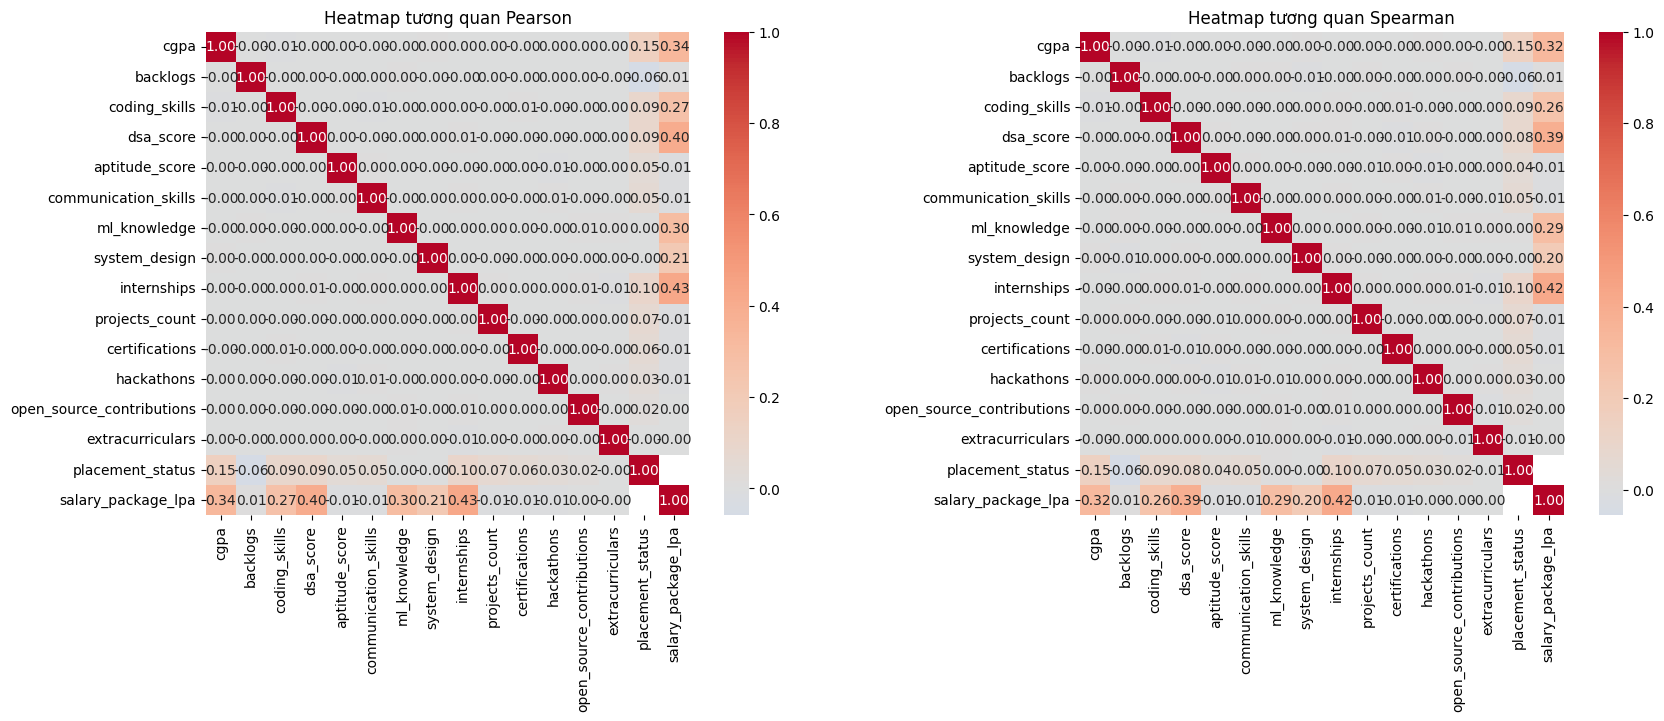

Số cặp có |r| > 0.9: 0
Không phát hiện cặp đa cộng tuyến mạnh theo ngưỡng đã chọn.


In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# Chỉ dùng các cột số có đủ dữ liệu để tính tương quan ổn định
corr_numeric_cols = [
    c for c in numeric_cols
    if pd.to_numeric(df_work[c], errors='coerce').dropna().nunique() >= 2
]

corr_df = df_work[corr_numeric_cols].apply(pd.to_numeric, errors='coerce')

pearson_corr = corr_df.corr(method='pearson')
spearman_corr = corr_df.corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(
    pearson_corr,
    cmap='coolwarm',
    center=0,
    annot=True,
    fmt='.2f',
    square=True,
    ax=axes[0]
)
axes[0].set_title('Heatmap tương quan Pearson')

sns.heatmap(
    spearman_corr,
    cmap='coolwarm',
    center=0,
    annot=True,
    fmt='.2f',
    square=True,
    ax=axes[1]
)
axes[1].set_title('Heatmap tương quan Spearman')

plt.tight_layout()
plt.show()

# Tìm các cặp có |r| > 0.9
threshold = 0.9
strong_pairs = []

for method_name, corr_matrix in [('Pearson', pearson_corr), ('Spearman', spearman_corr)]:
    cols = corr_matrix.columns
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            r = corr_matrix.iloc[i, j]
            if pd.notna(r) and abs(r) > threshold:
                strong_pairs.append({
                    'kiểu_tương_quan': method_name,
                    'biến_1': cols[i],
                    'biến_2': cols[j],
                    'hệ_số_r': round(float(r), 4),
                    'đề_xuất_xử_lý': 'Cân nhắc bỏ 1 biến hoặc dùng Regularization/PCA'
                })

strong_pairs_df = pd.DataFrame(strong_pairs)

print(f'Số cặp có |r| > {threshold}: {len(strong_pairs_df)}')
if len(strong_pairs_df) > 0:
    display(
        strong_pairs_df.style
        .set_properties(**{'text-align': 'left'})
        .set_table_styles([
            {'selector': 'th', 'props': [('text-align', 'left')]},
            {'selector': 'td', 'props': [('text-align', 'left')]}
        ])
    )
else:
    print('Không phát hiện cặp đa cộng tuyến mạnh theo ngưỡng đã chọn.')

#### **c) Phân tích giá trị thiếu**
Yêu cầu đề bài:
- Trực quan hóa ma trận thiếu dữ liệu (missing data matrix) bằng thư viện missingno.
- Kiểm định giả thuyết MCAR bằng Little's MCAR test.
- Phân loại cơ chế thiếu dữ liệu (MCAR/MAR/MNAR) và giải thích.

<Figure size 1400x600 with 0 Axes>

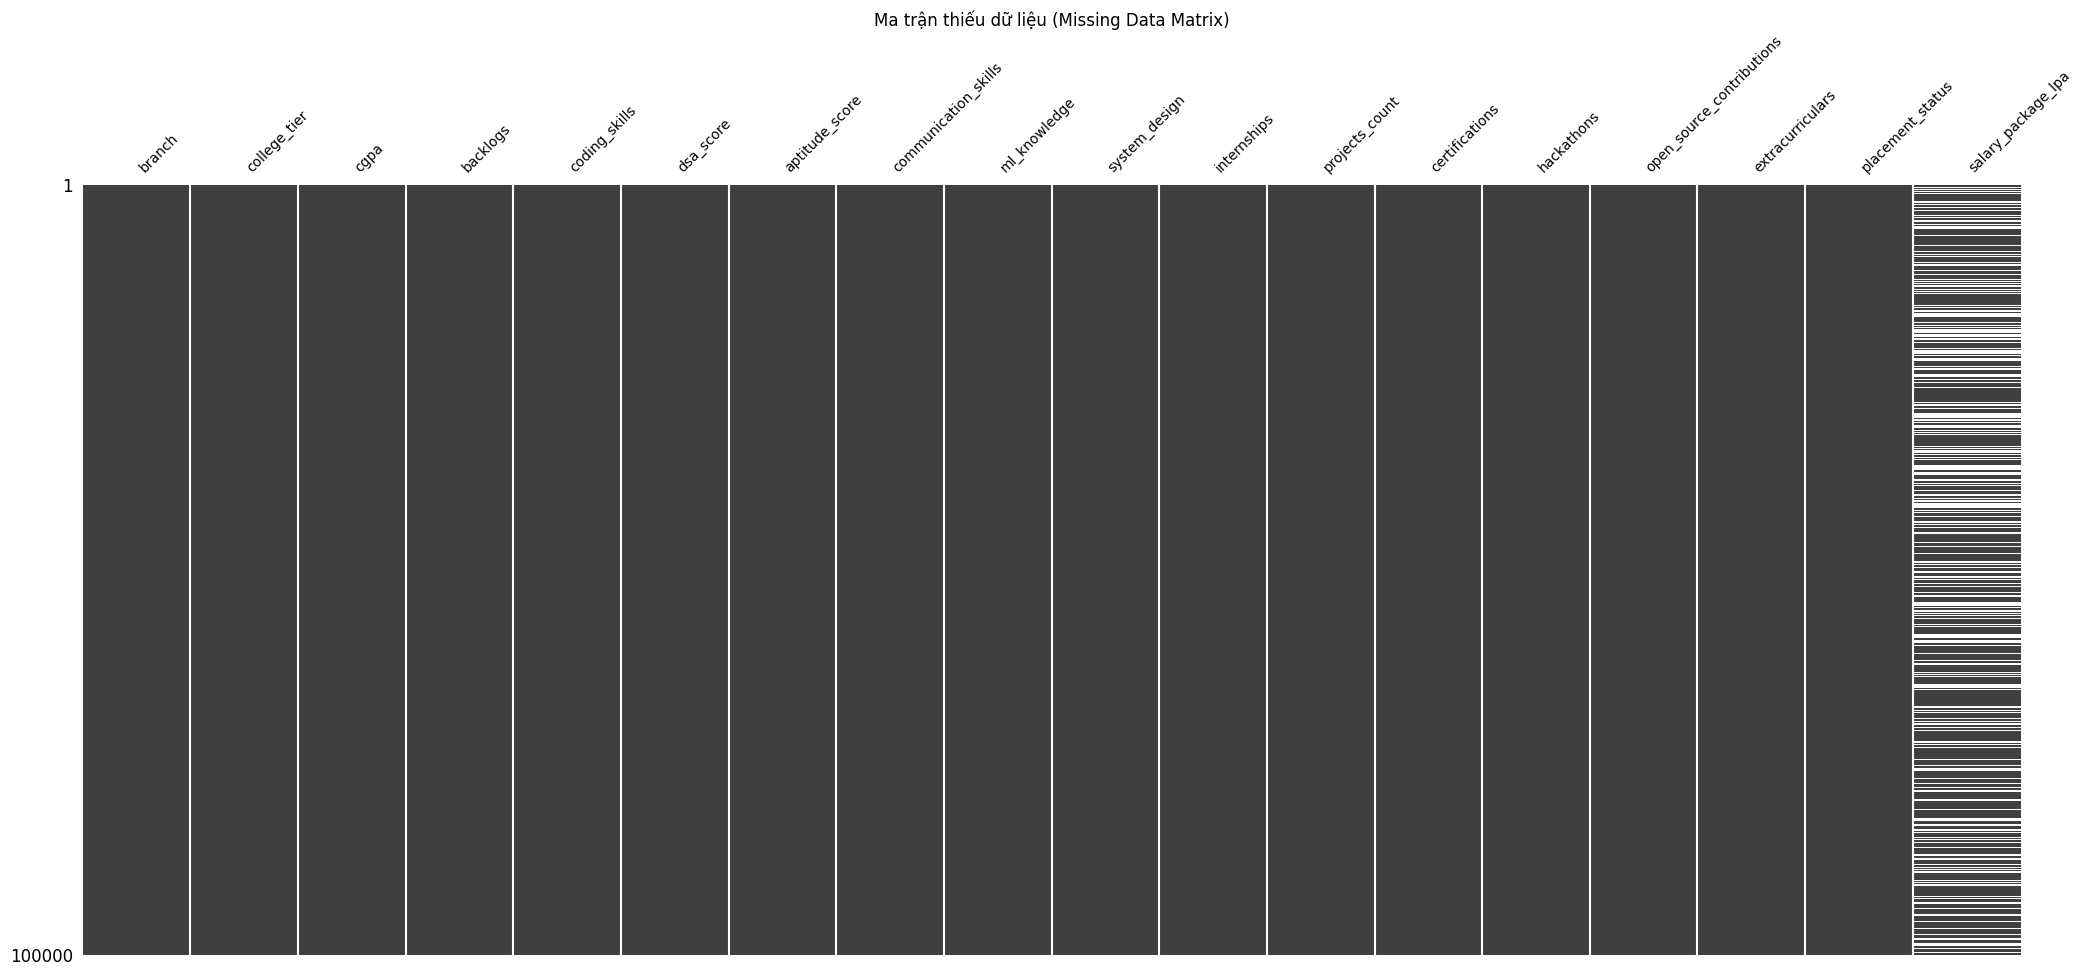

Little's MCAR test (custom) - statistic: 19998.9076, df: 17, p-value: 0.000000
Bác bỏ H0: dữ liệu thiếu không phải MCAR (nghiêng về MAR/MNAR).
Kết luận cơ chế thiếu dữ liệu: Không phải MCAR; khả năng MAR hoặc MNAR
Tỷ lệ thiếu trung bình toàn bảng: 1.75%


In [5]:
# Ma trận thiếu dữ liệu
try:
    import missingno as msno
    plt.figure(figsize=(14, 6))
    msno.matrix(df_work, sparkline=False, fontsize=10)
    plt.title('Ma trận thiếu dữ liệu (Missing Data Matrix)')
    plt.show()
except Exception as e:
    print('Không vẽ được bằng missingno, chuyển sang thống kê thiếu dạng bảng.')
    print(f'Lý do: {e}')
    missing_summary = pd.DataFrame({
        'cột': df_work.columns,
        'số_giá_trị_thiếu': df_work.isna().sum().values,
        'tỷ_lệ_thiếu_%': (df_work.isna().mean().values * 100).round(2)
    }).sort_values('tỷ_lệ_thiếu_%', ascending=False)
    display(missing_summary)

# Little's MCAR test
from scipy.stats import chi2

little_p_value = None
little_stat = None
little_df = None
little_conclusion = None

try:
    def little_mcar_test_custom(df):
        x = df.copy()

        # Mã hóa cột phân loại về số, giữ NaN
        for c in x.columns:
            if not pd.api.types.is_numeric_dtype(x[c]):
                cat = x[c].astype('category')
                x[c] = cat.cat.codes.replace(-1, np.nan)

        # Bỏ cột toàn NaN hoặc phương sai bằng 0 để tránh ma trận suy biến
        valid_cols = [c for c in x.columns if x[c].notna().sum() > 1 and x[c].nunique(dropna=True) > 1]
        x = x[valid_cols]

        if x.shape[1] == 0:
            raise ValueError('Không đủ cột hợp lệ để chạy Little MCAR test.')

        mu = x.mean(skipna=True).values
        cov = x.cov().values

        # Regularization nhẹ để ma trận khả nghịch ổn định
        cov = cov + np.eye(cov.shape[0]) * 1e-6

        miss_mask = x.isna().values
        patterns = pd.DataFrame(miss_mask).drop_duplicates().values

        stat = 0.0
        dof = 0

        x_values = x.values

        for p in patterns:
            row_idx = np.all(miss_mask == p, axis=1)
            n_g = int(row_idx.sum())
            if n_g == 0:
                continue

            observed_idx = np.where(~p)[0]
            if len(observed_idx) == 0:
                continue

            group_data = x_values[row_idx][:, observed_idx]

            group_data = group_data[~np.isnan(group_data).any(axis=1)]
            if len(group_data) == 0:
                continue

            mean_g = group_data.mean(axis=0)
            mu_o = mu[observed_idx]
            cov_oo = cov[np.ix_(observed_idx, observed_idx)]
            inv_cov_oo = np.linalg.pinv(cov_oo)

            diff = mean_g - mu_o
            stat += len(group_data) * float(diff.T @ inv_cov_oo @ diff)
            dof += len(observed_idx)

        dof = max(dof - x.shape[1], 1)
        p_value = 1 - chi2.cdf(stat, dof)
        return float(stat), int(dof), float(p_value)

    # Lấy mẫu để tăng tốc nhưng vẫn đủ ổn định thống kê
    sample_size = min(20000, len(df_work))
    mcar_sample = df_work.sample(n=sample_size, random_state=42)

    little_stat, little_df, little_p_value = little_mcar_test_custom(mcar_sample)

    if little_p_value >= 0.05:
        little_conclusion = 'Không bác bỏ H0: dữ liệu thiếu có xu hướng MCAR.'
    else:
        little_conclusion = 'Bác bỏ H0: dữ liệu thiếu không phải MCAR (nghiêng về MAR/MNAR).'

    print(
        f"Little's MCAR test (custom) - statistic: {little_stat:.4f}, "
        f"df: {little_df}, p-value: {little_p_value:.6f}"
    )
    print(little_conclusion)
except Exception as e:
    print("Chưa chạy được Little's MCAR test tự cài đặt.")
    print(f'Lý do: {e}')

# Kết luận cơ chế thiếu dữ liệu 
missing_any = df_work.isna().any().any()
if not missing_any:
    mechanism = 'Không có missing, không cần phân loại cơ chế thiếu.'
elif little_p_value is None:
    mechanism = 'Chưa kết luận được bằng Little MCAR test; tạm thời cần giả định MAR và kiểm chứng thêm theo ngữ cảnh.'
elif little_p_value >= 0.05:
    mechanism = 'MCAR (theo kiểm định Little, mức ý nghĩa 0.05).'
else:
    mechanism = 'Không phải MCAR; khả năng MAR hoặc MNAR'

print(f'Kết luận cơ chế thiếu dữ liệu: {mechanism}')

missing_overall = df_work.isna().mean().mean() * 100
print(f'Tỷ lệ thiếu trung bình toàn bảng: {missing_overall:.2f}%')


#### **2.2.3 Các kỹ thuật tiền xử lý và đánh giá định lượng**
#### **a) Xử lý giá trị thiếu có kiểm soát**

**(i) Cơ sở lý thuyết và công thức**

- **Cơ chế MCAR**: dữ liệu thiếu được tạo ngẫu nhiên, không phụ thuộc vào giá trị quan sát hay không quan sát.
- **Mục tiêu đánh giá**: tạo thiếu bổ sung 10% theo MCAR, điền khuyết bằng nhiều chiến lược, rồi so sánh sai số tại đúng các ô bị che.
- **Các chiến lược so sánh**: Mean, Median, Mode, k-NN (k=3,5,10), MICE (Iterative Imputer).

Giả sử $\Omega$ là tập chỉ số các ô bị che, $y_i$ là giá trị thật và $\hat{y}_i$ là giá trị điền khuyết:

$$
\mathrm{RMSE}=\sqrt{\frac{1}{|\Omega|}\sum_{i\in\Omega}(y_i-\hat{y}_i)^2}
$$

$$
\mathrm{MAE}=\frac{1}{|\Omega|}\sum_{i\in\Omega}|y_i-\hat{y}_i|
$$

Trong đó:
- $\Omega$: tập các vị trí bị che (missing nhân tạo) dùng để đánh giá.
- $|\Omega|$: số lượng phần tử trong tập $\Omega$.
- $y_i$: giá trị thật tại vị trí thứ $i$.
- $\hat{y}_i$: giá trị dự đoán/điền khuyết tại vị trí thứ $i$.
- RMSE: nhấn mạnh sai số lớn do có bình phương sai số.
- MAE: phản ánh sai số tuyệt đối trung bình, dễ diễn giải theo đơn vị gốc dữ liệu.

Tiêu chí chọn mô hình: ưu tiên **RMSE nhỏ nhất** (MAE dùng bổ trợ diễn giải).

**(ii) Cài đặt**

In [ ]:
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer  
from sklearn.impute import IterativeImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Chuẩn bị dữ liệu số cho điền khuyết
numeric_df = df_work[numeric_cols].apply(pd.to_numeric, errors='coerce').copy()
numeric_df = numeric_df.dropna(axis=1, how='all')

if numeric_df.shape[1] == 0:
    raise ValueError('Không có cột số hợp lệ')

# Dùng mẫu đại diện để kiểm soát thời gian tính toán cho kNN và MICE
sample_n = min(10000, len(numeric_df))
eval_df = numeric_df.sample(n=sample_n, random_state=42).reset_index(drop=True)

observed_positions = np.argwhere(eval_df.notna().values)
if len(observed_positions) < 100:
    raise ValueError('Không đủ giá trị quan sát để tạo bộ kiểm thử imputation.')

# Tạo missing nhân tạo 10% theo MCAR
rng = np.random.default_rng(42)
mask_size = max(int(0.10 * len(observed_positions)), 1)
chosen_idx = rng.choice(len(observed_positions), size=mask_size, replace=False)
test_positions = observed_positions[chosen_idx]

masked_df = eval_df.copy()
for r, c in test_positions:
    masked_df.iat[r, c] = np.nan

y_true = np.array([eval_df.iat[r, c] for r, c in test_positions], dtype=float)

imputers = {
    'Mean': SimpleImputer(strategy='mean'),
    'Median': SimpleImputer(strategy='median'),
    'Mode': SimpleImputer(strategy='most_frequent'),
    'KNN_k3': KNNImputer(n_neighbors=3, weights='distance'),
    'KNN_k5': KNNImputer(n_neighbors=5, weights='distance'),
    'KNN_k10': KNNImputer(n_neighbors=10, weights='distance'),
    'MICE': IterativeImputer(random_state=42, max_iter=20)
}

results = []

for name, imputer in imputers.items():
    try:
        imputed_arr = imputer.fit_transform(masked_df)
        y_pred = np.array([imputed_arr[r, c] for r, c in test_positions], dtype=float)

        rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
        mae = float(mean_absolute_error(y_true, y_pred))

        if name.startswith('KNN_'):
            family = 'k-NN Imputation'
        elif name == 'MICE':
            family = 'MICE (Iterative)'
        else:
            family = 'Simple Imputation'

        results.append({
            'Chiến lược': name,
            'Nhóm': family,
            'RMSE': round(rmse, 6),
            'MAE': round(mae, 6),
            'Tỉ lệ MCAR_%': 10
        })
    except Exception as e:
        results.append({
            'Chiến lược': name,
            'Nhóm': 'Lỗi thực thi',
            'RMSE': np.nan,
            'MAE': np.nan,
            'Tỉ lệ MCAR_%': 10,
            'ghi_chu': f'Loi: {e}'
        })

imputation_eval_df = pd.DataFrame(results).sort_values('RMSE', na_position='last').reset_index(drop=True)

print('Bảng so sánh chiến lược điền khuyết')
display(
    imputation_eval_df.style
    .set_properties(**{'text-align': 'left'})
    .set_table_styles([
        {'selector': 'th', 'props': [('text-align', 'left')]},
        {'selector': 'td', 'props': [('text-align', 'left')]}
    ])
)

valid_eval = imputation_eval_df.dropna(subset=['RMSE'])
if len(valid_eval) == 0:
    raise RuntimeError('Không có chiến lược nào chạy thành công')

best_method = valid_eval.iloc[0]['Chiến lược']
best_rmse = float(valid_eval.iloc[0]['RMSE'])

print(f'\nChiến lược tốt nhất theo RMSE thấp nhất: {best_method} (RMSE={best_rmse:.6f})')
if best_method.startswith('KNN_'):
    rationale = 'kNN tận dụng cấu trúc lân cận giữa các mẫu nên phục hồi tốt hơn trên bộ dữ liệu này.'
elif best_method == 'MICE':
    rationale = 'MICE mô hình hóa quan hệ giữa các biến theo chuỗi lặp, phù hợp dữ liệu có tương quan.'
else:
    rationale = 'Chiến lược đơn giản nhưng ổn định, phù hợp đặc trưng phân phối hiện tại của dữ liệu.'
print(f'Lý giải lựa chọn: {rationale}')

# Áp dụng chiến lược tốt nhất lên dữ liệu thật
best_imputer = imputers[best_method]
df_imputed = df_work.copy()

num_data_full = df_imputed[numeric_df.columns].apply(pd.to_numeric, errors='coerce')
num_imputed_full = best_imputer.fit_transform(num_data_full)
df_imputed[numeric_df.columns] = num_imputed_full

# Điền mode cho cột phân loại còn thiếu
cat_missing_cols = []
for col in df_imputed.select_dtypes(exclude=[np.number]).columns:
    if df_imputed[col].isna().any():
        mode_vals = df_imputed[col].mode(dropna=True)
        if len(mode_vals) > 0:
            df_imputed[col] = df_imputed[col].fillna(mode_vals.iloc[0])
            cat_missing_cols.append(col)

missing_before = int(df_work.isna().sum().sum())
missing_after = int(df_imputed.isna().sum().sum())

print(f'Tổng số giá trị thiếu trước xử lý: {missing_before}')
print(f'Tổng số giá trị thiếu sau xử lý: {missing_after}')
print(f'Số cột phân loại được điền bằng mode: {len(cat_missing_cols)}')

Bảng so sánh chiến lược điền khuyết


d:\data-mining-lab01\.venv\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


,Chiến lược,Nhóm,RMSE,MAE,Tỉ lệ MCAR_%
0,MICE,MICE (Iterative),3.327376,1.556816,10
1,Mean,Simple Imputation,3.364532,1.608851,10
2,Median,Simple Imputation,3.380837,1.573029,10
3,Mode,Simple Imputation,3.400165,1.594815,10
4,KNN_k10,k-NN Imputation,3.534252,1.655577,10
5,KNN_k5,k-NN Imputation,3.654416,1.719864,10
6,KNN_k3,k-NN Imputation,3.870422,1.804174,10



Chiến lược tốt nhất theo RMSE thấp nhất: MICE (RMSE=3.327376)
Lý giải lựa chọn: MICE mô hình hóa quan hệ giữa các biến theo chuỗi lặp, phù hợp dữ liệu có tương quan.
Tổng số giá trị thiếu trước xử lý: 31525
Tổng số giá trị thiếu sau xử lý: 0
Số cột phân loại được điền bằng mode: 0


#### **b) Phát hiện và xử lý ngoại lai bằng nhiều kỹ thuật**

**(i) Cơ sở lý thuyết và công thức**

- **IQR**: đánh dấu ngoại lai nếu giá trị nằm ngoài khoảng $[Q1 - 1.5\times IQR,\; Q3 + 1.5\times IQR]$.
- **Z-score**: với mỗi thuộc tính chuẩn hóa $z=(x-\mu)/\sigma$, điểm có $|z|>3$ được xem là ngoại lai.
- **Isolation Forest**: tách điểm bằng cây ngẫu nhiên, điểm dễ bị cô lập được xem là ngoại lai.
- **LOF (Local Outlier Factor)**: so sánh mật độ cục bộ của điểm với lân cận; mật độ thấp bất thường là ngoại lai.
- **DBSCAN**: điểm bị gán nhãn nhiễu (label = -1) sau khi gom cụm được xem là ngoại lai.

Trong đó (cho các công thức ngưỡng):
- $Q1, Q3$: tứ phân vị 25% và 75%.
- $IQR = Q3-Q1$: khoảng tứ phân vị.
- $x$: giá trị quan sát cần kiểm tra.
- $\mu, \sigma$: trung bình và độ lệch chuẩn của thuộc tính.
- $z$: điểm chuẩn hóa Z-score.

Độ chồng chéo giữa hai tập ngoại lai $A,B$ được đo bằng **Jaccard similarity**:

$$
J(A,B)=\frac{|A\cap B|}{|A\cup B|}
$$

Trong đó:
- $A, B$: hai tập chỉ số điểm bị gắn nhãn ngoại lai bởi hai phương pháp.
- $|A\cap B|$: số điểm ngoại lai chung giữa hai phương pháp.
- $|A\cup B|$: tổng số điểm bị gắn ngoại lai bởi ít nhất một trong hai phương pháp.
- $J(A,B)\in[0,1]$: càng gần 1 thì mức đồng thuận càng cao.

Tác động của loại bỏ ngoại lai lên phân phối được kiểm định bằng **Kolmogorov-Smirnov (KS)** giữa phân phối trước và sau xử lý trên từng thuộc tính số, với thống kê:

$$
D_{n,m}=\sup_x\left|F_n(x)-G_m(x)\right|
$$

Trong đó:
- $F_n(x), G_m(x)$: hàm phân phối thực nghiệm trước và sau xử lý.
- $n, m$: cỡ mẫu của hai tập so sánh.
- $D_{n,m}$: độ lệch lớn nhất giữa hai phân phối thực nghiệm.

**(ii) Cài đặt**

In [8]:
from scipy.stats import zscore, ks_2samp
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor, NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# Ưu tiên dữ liệu đã xử lý thiếu từ 2.2.3(a)
if 'df_imputed' in globals():
    outlier_base_df = df_imputed.copy()
else:
    outlier_base_df = df_work.copy()
    # Fallback: điền median cho cột số nếu chưa chạy 2.2.3(a)
    for c in numeric_cols:
        outlier_base_df[c] = pd.to_numeric(outlier_base_df[c], errors='coerce')
        med = outlier_base_df[c].median()
        outlier_base_df[c] = outlier_base_df[c].fillna(med)

num_cols_outlier = [c for c in numeric_cols if c in outlier_base_df.columns]
X_full = outlier_base_df[num_cols_outlier].apply(pd.to_numeric, errors='coerce')
X_full = X_full.dropna(axis=1, how='all')
X_full = X_full.fillna(X_full.median())

if X_full.shape[1] == 0:
    raise ValueError('Không có cột số hợp lệ để phát hiện ngoại lai.')

def detect_outliers_by_method(X_df, method_name):
    if len(X_df) < 3:
        return set()

    if method_name == 'IQR':
        q1 = X_df.quantile(0.25)
        q3 = X_df.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        mask = ((X_df < lower) | (X_df > upper)).any(axis=1)
        return set(X_df.index[mask])

    if method_name == 'Z-score':
        z_abs = np.abs(zscore(X_df, nan_policy='omit'))
        z_df = pd.DataFrame(np.asarray(z_abs), index=X_df.index, columns=X_df.columns)
        mask = (z_df > 3).any(axis=1)
        return set(X_df.index[mask])

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_df)

    if method_name.startswith('IsolationForest_c'):
        cont = float(method_name.split('c')[-1])
        iso = IsolationForest(
            n_estimators=200,
            contamination=cont,
            random_state=42,
            n_jobs=-1
        )
        pred = iso.fit_predict(X_scaled)
        return set(X_df.index[pred == -1])

    if method_name.startswith('LOF_k'):
        k = int(method_name.split('k')[-1])
        k = min(k, max(2, len(X_df) - 1))
        lof = LocalOutlierFactor(n_neighbors=k, contamination='auto')
        pred = lof.fit_predict(X_scaled)
        return set(X_df.index[pred == -1])

    if method_name == 'DBSCAN':
        n_nb = min(20, max(2, len(X_df) - 1))
        nn = NearestNeighbors(n_neighbors=n_nb)
        nn.fit(X_scaled)
        distances, _ = nn.kneighbors(X_scaled)
        eps = float(np.quantile(distances[:, -1], 0.95))
        dbscan = DBSCAN(eps=eps, min_samples=n_nb)
        labels = dbscan.fit_predict(X_scaled)
        return set(X_df.index[labels == -1])

    raise ValueError(f'Phương pháp không hỗ trợ: {method_name}')

outlier_sample_n = min(30000, len(X_full))
X = X_full.sample(n=outlier_sample_n, random_state=42).copy()

benchmark_methods = [
    'IQR', 'Z-score',
    'IsolationForest_c0.01', 'IsolationForest_c0.05', 'IsolationForest_c0.1',
    'LOF_k10', 'LOF_k20', 'LOF_k50',
    'DBSCAN'
 ]

method_outliers = {m: detect_outliers_by_method(X, m) for m in benchmark_methods}

# Báo cáo tỉ lệ ngoại lai trên sample
rate_rows = []
for m, idx_set in method_outliers.items():
    rate_rows.append({
        'Phương pháp': m,
        'Số ngoại lai': len(idx_set),
        'ti_le_ngoai_lai_%': round(100 * len(idx_set) / len(X), 4)
    })
outlier_rate_df = pd.DataFrame(rate_rows).sort_values('ti_le_ngoai_lai_%').reset_index(drop=True)

print(f'Số mẫu benchmark outlier: {len(X):,}')
print('Bảng tỉ lệ phát hiện ngoại lai theo từng phương pháp (sample):')
display(
    outlier_rate_df.style
    .set_properties(**{'text-align': 'left'})
    .set_table_styles([
        {'selector': 'th', 'props': [('text-align', 'left')]},
        {'selector': 'td', 'props': [('text-align', 'left')]}
    ])
)

# Ma trận Jaccard giữa các phương pháp (trên sample)
methods = list(method_outliers.keys())
jaccard_mat = pd.DataFrame(index=methods, columns=methods, dtype=float)
for m1 in methods:
    s1 = method_outliers[m1]
    for m2 in methods:
        s2 = method_outliers[m2]
        union = len(s1 | s2)
        jac = 1.0 if union == 0 else len(s1 & s2) / union
        jaccard_mat.loc[m1, m2] = jac

print('Ma trận Jaccard similarity giữa các tập ngoại lai (sample):')
display(
    jaccard_mat.round(4).style
    .set_properties(**{'text-align': 'left'})
    .set_table_styles([
        {'selector': 'th', 'props': [('text-align', 'left')]},
        {'selector': 'td', 'props': [('text-align', 'left')]}
    ])
)

# Đánh giá tác động lên phân phối bằng KS (trên sample)
ks_rows = []
for m, idx_set in method_outliers.items():
    X_clean = X.loc[~X.index.isin(idx_set)]

    ks_stats = []
    ks_pvals = []
    for c in X.columns:
        base = X[c].dropna().values
        clean = X_clean[c].dropna().values
        if len(base) < 20 or len(clean) < 20:
            continue
        stat, pval = ks_2samp(base, clean)
        ks_stats.append(float(stat))
        ks_pvals.append(float(pval))

    if len(ks_stats) == 0:
        ks_rows.append({
            'Phương pháp': m,
            'ks_stat_tb': np.nan,
            'Tỉ lệ thuộc tính p<0.05_%': np.nan,
            'Số thuộc tính KS hợp lệ': 0
        })
    else:
        ks_rows.append({
            'Phương pháp': m,
            'ks_stat_tb': round(float(np.mean(ks_stats)), 4),
            'Tỉ lệ thuộc tính p<0.05_%': round(float(np.mean(np.array(ks_pvals) < 0.05) * 100), 2),
            'Số thuộc tính KS hợp lệ': len(ks_stats)
        })

ks_impact_df = pd.DataFrame(ks_rows).sort_values('ks_stat_tb', na_position='last').reset_index(drop=True)

print('Tác động của loại bỏ ngoại lai lên phân phối (KS) trên sample:')
display(
    ks_impact_df.style
    .set_properties(**{'text-align': 'left'})
    .set_table_styles([
        {'selector': 'th', 'props': [('text-align', 'left')]},
        {'selector': 'td', 'props': [('text-align', 'left')]}
    ])
)

# Chọn phương pháp tốt nhất từ sample: ưu tiên ks_stat_tb thấp, tie-break theo tỉ lệ outlier thấp
select_df = outlier_rate_df.merge(ks_impact_df, on='Phương pháp', how='left')
select_df = select_df[(select_df['Số ngoại lai'] > 0) & (select_df['ks_stat_tb'].notna())]

if len(select_df) == 0:
    raise RuntimeError('Không chọn được phương pháp outlier từ sample.')

best_outlier_method = select_df.sort_values(
    ['ks_stat_tb', 'ti_le_ngoai_lai_%'],
    ascending=[True, True]
).iloc[0]['Phương pháp']

print(f'\nPhương pháp outlier được chọn từ sample: {best_outlier_method}')

# Áp dụng phương pháp đã chọn lên full data 
full_outlier_idx = detect_outliers_by_method(X_full, best_outlier_method)
df_outlier_processed = outlier_base_df.loc[~outlier_base_df.index.isin(full_outlier_idx)].copy()

print(f'Số dòng full trước xử lý outlier: {len(outlier_base_df):,}')
print(f'Số outlier loại bỏ trên full: {len(full_outlier_idx):,}')
print(f'Số dòng sau xử lý outlier: {len(df_outlier_processed):,}')

Số mẫu benchmark outlier: 30,000
Bảng tỉ lệ phát hiện ngoại lai theo từng phương pháp (sample):


,Phương pháp,Số ngoại lai,ti_le_ngoai_lai_%
0,LOF_k50,1,0.003300
1,LOF_k20,2,0.006700
2,LOF_k10,4,0.013300
3,DBSCAN,53,0.176700
4,IsolationForest_c0.01,300,1.000000
5,Z-score,309,1.030000
6,IsolationForest_c0.05,1500,5.000000
7,IsolationForest_c0.1,3000,10.000000
8,IQR,7690,25.633300


Ma trận Jaccard similarity giữa các tập ngoại lai (sample):


,IQR,Z-score,IsolationForest_c0.01,IsolationForest_c0.05,IsolationForest_c0.1,LOF_k10,LOF_k20,LOF_k50,DBSCAN
IQR,1.000000,0.040200,0.030800,0.131200,0.220000,0.000500,0.000300,0.000100,0.005700
Z-score,0.040200,1.000000,0.035700,0.034300,0.031500,0.009700,0.006500,0.003200,0.040200
IsolationForest_c0.01,0.030800,0.035700,1.000000,0.200000,0.100000,0.003300,0.006700,0.003300,0.124200
IsolationForest_c0.05,0.131200,0.034300,0.200000,1.000000,0.500000,0.002000,0.001300,0.000700,0.034600
IsolationForest_c0.1,0.220000,0.031500,0.100000,0.500000,1.000000,0.001000,0.000700,0.000300,0.017300
LOF_k10,0.000500,0.009700,0.003300,0.002000,0.001000,1.000000,0.200000,0.250000,0.036400
LOF_k20,0.000300,0.006500,0.006700,0.001300,0.000700,0.200000,1.000000,0.500000,0.037700
LOF_k50,0.000100,0.003200,0.003300,0.000700,0.000300,0.250000,0.500000,1.000000,0.018900
DBSCAN,0.005700,0.040200,0.124200,0.034600,0.017300,0.036400,0.037700,0.018900,1.000000


Tác động của loại bỏ ngoại lai lên phân phối (KS) trên sample:


,Phương pháp,ks_stat_tb,Tỉ lệ thuộc tính p<0.05_%,Số thuộc tính KS hợp lệ
0,LOF_k20,0.000000,0.000000,16
1,LOF_k50,0.000000,0.000000,16
2,LOF_k10,0.000100,0.000000,16
3,DBSCAN,0.000400,0.000000,16
4,Z-score,0.001000,0.000000,16
5,IsolationForest_c0.01,0.002000,0.000000,16
6,IsolationForest_c0.05,0.007800,25.000000,16
7,IsolationForest_c0.1,0.013800,43.750000,16
8,IQR,0.015700,25.000000,16



Phương pháp outlier được chọn từ sample: LOF_k50
Số dòng full trước xử lý outlier: 100,000
Số outlier loại bỏ trên full: 2
Số dòng sau xử lý outlier: 99,998


**Phân tích kết quả (KS)**

- Bảng KS so sánh phân phối **trước** và **sau** khi loại ngoại lai theo từng phương pháp.
- Cột `ks_stat_tb` là độ lệch phân phối trung bình trên các thuộc tính số:
  - Giá trị **càng nhỏ** -> phân phối sau xử lý **càng gần** phân phối ban đầu.
- Cột `Tỉ lệ thuộc tính p<0.05_%` cho biết tỉ lệ thuộc tính có thay đổi phân phối có ý nghĩa thống kê:
  - Giá trị **càng cao** -> càng nhiều thuộc tính bị thay đổi mạnh sau khi loại ngoại lai.

**Nhận xét**

1. Nhóm tác động rất nhẹ lên phân phối: `LOF_k20`, `LOF_k50`, `LOF_k10`, `DBSCAN`, `Z-score`, `IsolationForest_c0.01` (KS trung bình rất thấp, tỉ lệ p<0.05 gần 0%).
2. Nhóm tác động trung bình: `IsolationForest_c0.05` và `IQR` (tỉ lệ p<0.05 khoảng 25%).
3. Nhóm tác động mạnh nhất: `IsolationForest_c0.1` (tỉ lệ p<0.05 cao nhất, ~43.75%).

#### **c) Chuẩn hóa dữ liệu có kiểm định**

**(i) Cơ sở lý thuyết và công thức**

Áp dụng và so sánh 5 biến thể chuẩn hóa:
- Min-Max Scaling
- Z-score (Standard Scaling)
- Robust Scaling
- Quantile Transform (output = uniform)
- Quantile Transform (output = normal)

Các công thức chuẩn hóa điển hình:

$$
x'_{\mathrm{minmax}}=\frac{x-x_{\min}}{x_{\max}-x_{\min}}
$$

$$
x'_{\mathrm{zscore}}=\frac{x-\mu}{\sigma}
$$

$$
x'_{\mathrm{robust}}=\frac{x-\mathrm{median}(x)}{\mathrm{IQR}}
$$

Trong đó:
- $x$: giá trị gốc.
- $x'$: giá trị sau chuẩn hóa.
- $x_{\min}, x_{\max}$: giá trị nhỏ nhất/lớn nhất của thuộc tính.
- $\mu, \sigma$: trung bình và độ lệch chuẩn.
- $\mathrm{median}(x)$: trung vị.
- $\mathrm{IQR}=Q3-Q1$: khoảng tứ phân vị.

Kiểm định Levene được dùng để đánh giá tính đồng nhất phương sai giữa các thuộc tính số sau chuẩn hóa. Thống kê kiểm định:

$$
W=\frac{(N-k)}{(k-1)}\cdot\frac{\sum_{i=1}^{k} n_i(\bar{Z}_{i\cdot}-\bar{Z}_{\cdot\cdot})^2}{\sum_{i=1}^{k}\sum_{j=1}^{n_i}(Z_{ij}-\bar{Z}_{i\cdot})^2},\quad Z_{ij}=|Y_{ij}-\tilde{Y}_i|
$$

Trong đó:
- $k$: số nhóm (ở đây là các thuộc tính số so sánh).
- $n_i$: số quan sát của nhóm $i$; $N=\sum_i n_i$.
- $Y_{ij}$: quan sát thứ $j$ của nhóm $i$.
- $\tilde{Y}_i$: giá trị trung tâm của nhóm $i$ (trong notebook dùng median).
- $Z_{ij}$: độ lệch tuyệt đối tới trung tâm nhóm.
- $\bar{Z}_{i\cdot}, \bar{Z}_{\cdot\cdot}$: trung bình theo nhóm và trung bình toàn cục của $Z$.

Giả thuyết kiểm định:
- $H_0$: phương sai giữa các nhóm là bằng nhau (homoscedasticity).
- $H_1$: có ít nhất một nhóm có phương sai khác biệt.

Nếu $p \ge 0.05$ thì chưa đủ bằng chứng bác bỏ $H_0$ (nghiêng về đồng nhất phương sai).

**(ii) Cài đặt**

Số mẫu dùng cho so sánh chuẩn hóa: 20,000
Kết quả Levene test sau từng phương pháp chuẩn hóa:


,phuong_phap,levene_stat,p_value,ket_luan_homoscedastic_0.05
0,MinMax,1560.060463,0.000000,False
1,Z-score,120.811228,0.000000,False
2,Robust,1338.546560,0.000000,False
3,Quantile-Uniform,390.905282,0.000000,False
4,Quantile-Normal,3385.829083,0.000000,False


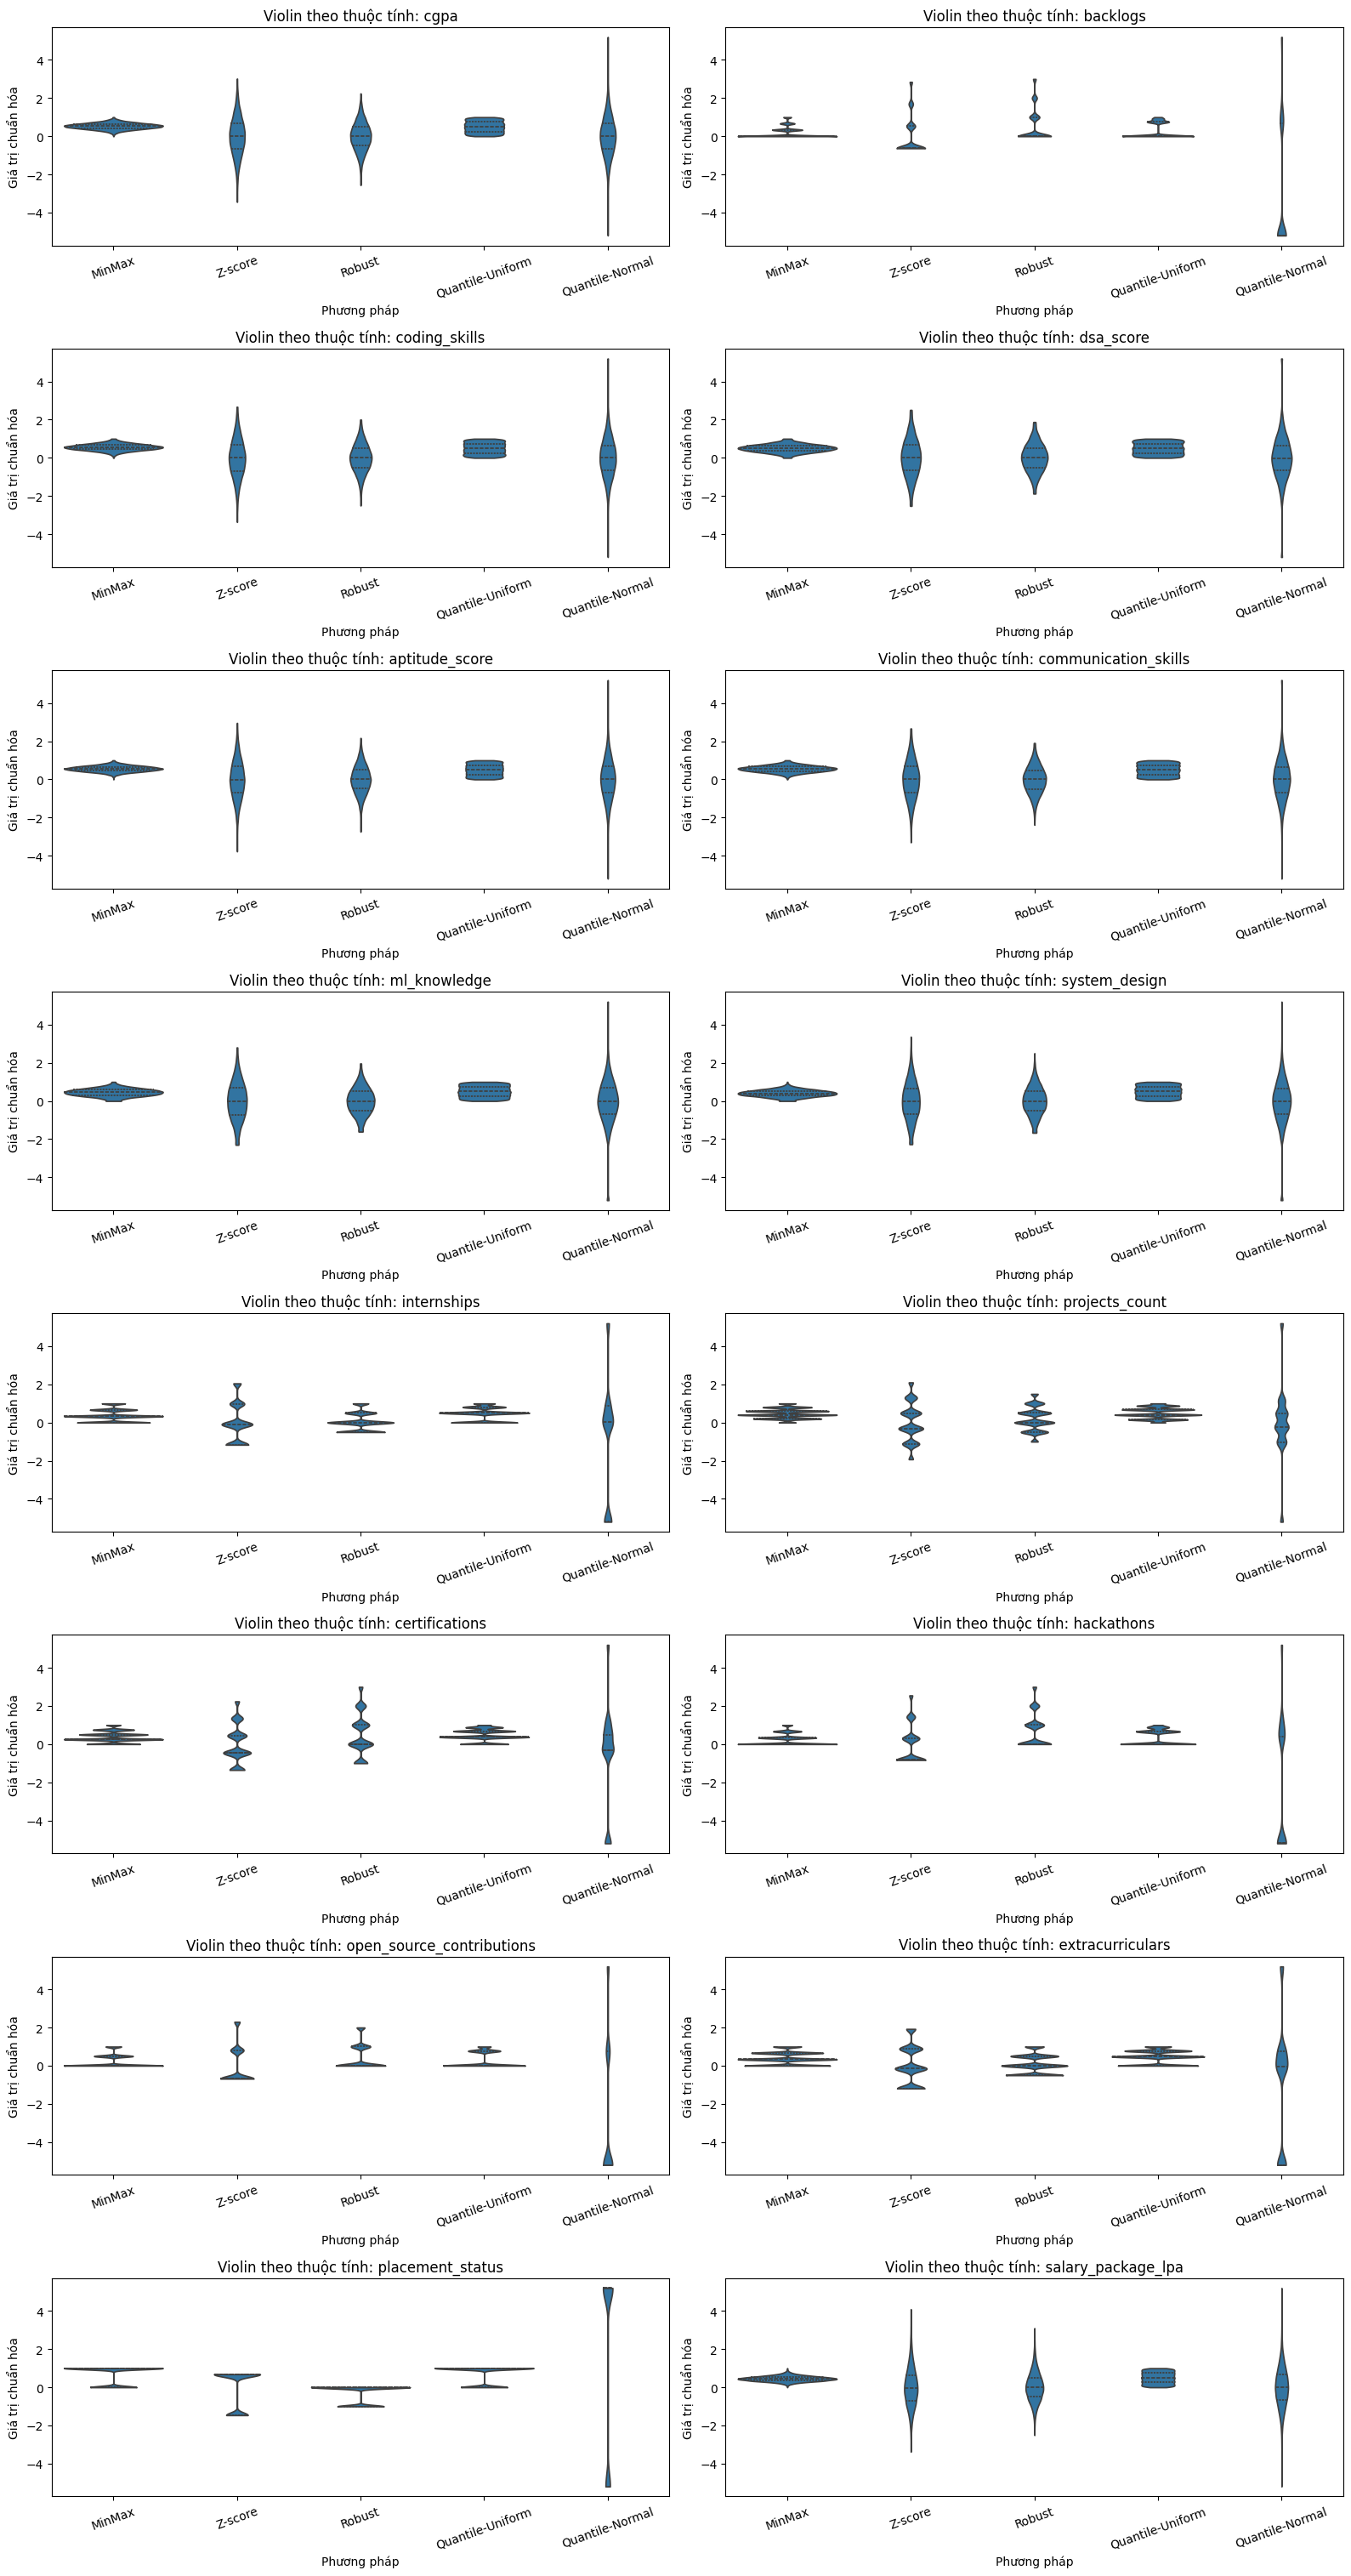

- Mỗi biểu đồ con là một thuộc tính; trục x là các cách chuẩn hóa để đối chiếu trực tiếp.
- p-value Levene nhỏ cho thấy phương sai giữa các thuộc tính vẫn chưa đồng nhất hoàn toàn.

Scaler áp dụng cuối trên full data: RobustScaler
Kích thước dữ liệu sau scaling (full): (99998, 18)


In [ ]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, QuantileTransformer
from scipy.stats import levene

# Ưu tiên dữ liệu đã xử lý outlier từ 2.2.3(b), sau đó mới fallback
if 'df_outlier_processed' in globals():
    scale_base_df = df_outlier_processed.copy()
elif 'df_imputed' in globals():
    scale_base_df = df_imputed.copy()
else:
    scale_base_df = df_work.copy()

num_cols_scale = [c for c in numeric_cols if c in scale_base_df.columns]
X_scale_full = scale_base_df[num_cols_scale].apply(pd.to_numeric, errors='coerce')
X_scale_full = X_scale_full.dropna(axis=1, how='all')
X_scale_full = X_scale_full.fillna(X_scale_full.median())

if X_scale_full.shape[1] < 2:
    raise ValueError('Cần ít nhất 2 thuộc tính số để kiểm định Levene.')

scale_sample_n = min(20000, len(X_scale_full))
X_scale = X_scale_full.sample(n=scale_sample_n, random_state=42).copy()

scalers = {
    'MinMax': MinMaxScaler(),
    'Z-score': StandardScaler(),
    'Robust': RobustScaler(),
    'Quantile-Uniform': QuantileTransformer(output_distribution='uniform', random_state=42),
    'Quantile-Normal': QuantileTransformer(output_distribution='normal', random_state=42)
}

scaled_data = {}
levene_rows = []

for name, scaler in scalers.items():
    X_arr = scaler.fit_transform(X_scale)
    X_df = pd.DataFrame(X_arr, columns=X_scale.columns, index=X_scale.index)
    scaled_data[name] = X_df

    # Levene test trên các thuộc tính số sau chuẩn hóa
    groups = [X_df[c].dropna().values for c in X_df.columns]
    groups = [g for g in groups if len(g) >= 20]
    if len(groups) < 2:
        lev_stat, lev_p = np.nan, np.nan
    else:
        lev_stat, lev_p = levene(*groups, center='median')

    levene_rows.append({
        'phuong_phap': name,
        'levene_stat': round(float(lev_stat), 6) if pd.notna(lev_stat) else np.nan,
        'p_value': round(float(lev_p), 6) if pd.notna(lev_p) else np.nan,
        'ket_luan_homoscedastic_0.05': bool(lev_p >= 0.05) if pd.notna(lev_p) else np.nan
    })

levene_df = pd.DataFrame(levene_rows).sort_values('p_value', na_position='last').reset_index(drop=True)

print(f'Số mẫu dùng cho so sánh chuẩn hóa: {len(X_scale):,}')
print('Kết quả Levene test sau từng phương pháp chuẩn hóa:')
display(
    levene_df.style
    .set_properties(**{'text-align': 'left'})
    .set_table_styles([
        {'selector': 'th', 'props': [('text-align', 'left')]},
        {'selector': 'td', 'props': [('text-align', 'left')]}
    ])
)

# Violin plot 
plot_cols = X_scale.columns.tolist()

plot_frames = []
for method_name, X_df in scaled_data.items():
    tmp = X_df[plot_cols].copy()
    tmp['Phương pháp'] = method_name
    long_df = tmp.melt(id_vars='Phương pháp', var_name='Thuộc tính', value_name='Giá trị chuẩn hóa')
    plot_frames.append(long_df)

plot_all = pd.concat(plot_frames, axis=0, ignore_index=True)

n_attr = len(plot_cols)
n_cols = 2 if n_attr > 1 else 1
n_rows = int(np.ceil(n_attr / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(8 * n_cols, 3.8 * n_rows), sharey=False)
if n_rows == 1 and n_cols == 1:
    axes = np.array([axes])
axes = np.array(axes).reshape(-1)

for i, attr in enumerate(plot_cols):
    ax = axes[i]
    d = plot_all[plot_all['Thuộc tính'] == attr]
    sns.violinplot(
        data=d,
        x='Phương pháp',
        y='Giá trị chuẩn hóa',
        inner='quartile',
        cut=0,
        ax=ax
    )
    ax.set_title(f'Violin theo thuộc tính: {attr}')
    ax.tick_params(axis='x', rotation=20)

for j in range(len(plot_cols), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

print('- Mỗi biểu đồ con là một thuộc tính; trục x là các cách chuẩn hóa để đối chiếu trực tiếp.')
print('- p-value Levene nhỏ cho thấy phương sai giữa các thuộc tính vẫn chưa đồng nhất hoàn toàn.')

# Áp dụng scaler đã chọn lên full data
scaler_apply_map = {
    'StandardScaler (Z-score)': StandardScaler(),
    'QuantileTransformer': QuantileTransformer(output_distribution='normal', random_state=42),
    'RobustScaler': RobustScaler()
}

if 'chosen_scaler' in globals() and chosen_scaler in scaler_apply_map:
    final_scaler_name = chosen_scaler
else:
    final_scaler_name = 'RobustScaler'

final_scaler = scaler_apply_map[final_scaler_name]
df_scaled_processed = scale_base_df.copy()
df_scaled_processed[X_scale_full.columns] = final_scaler.fit_transform(X_scale_full)

print(f'\nScaler áp dụng cuối trên full data: {final_scaler_name}')
print(f'Kích thước dữ liệu sau scaling (full): {df_scaled_processed.shape}')

**Đánh giá kết quả chuẩn hóa (Levene + Violin)**

Kết quả Levene ở cả 5 phương pháp đều cho p-value rất nhỏ, vì vậy tại mức ý nghĩa 0.05 có thể bác bỏ $H_0$ và kết luận phương sai giữa các thuộc tính vẫn còn khác biệt. Giá trị `0.000000` trên bảng là do làm tròn khi hiển thị, không phải p-value bằng 0 tuyệt đối.

Quan sát violin plot theo từng thuộc tính cho thấy:
- MinMax và Z-score giữ hình dạng dữ liệu khá trực quan, nhưng vẫn nhạy với ngoại lai.
- Robust ổn định hơn ở các thuộc tính có đuôi dài hoặc chứa nhiều giá trị cực trị.
- Quantile (uniform/normal) làm thay đổi phân phối mạnh hơn, phù hợp khi cần giảm độ lệch rõ rệt.

**Kết luận:** lựa chọn phương pháp chuẩn hóa cần bám theo mục tiêu phân tích. Nếu ưu tiên tính bền vững trước ngoại lai, nên dùng Robust hoặc Quantile. Nếu ưu tiên khả năng diễn giải theo thang đo quen thuộc nên dùng MinMax hoặc Z-score.

#### **d) Mã hóa biến phân loại nâng cao và đánh giá đa cộng tuyến (VIF)**

**(i) Cơ sở lý thuyết và công thức**

Áp dụng và so sánh 5 cách mã hóa:
- One-Hot Encoding
- Ordinal Encoding
- Target Encoding (mean encoding) theo K-Fold để hạn chế target leakage
- Binary Encoding cho thuộc tính có số giá trị khác nhau > 20
- Frequency Encoding

Một số công thức:

- **Target Encoding** (trung bình mục tiêu theo nhóm):

$$
\mathrm{TE}(c)=\frac{1}{n_c}\sum_{i:x_i=c} y_i
$$

Trong đó:
- $c$: một giá trị phân loại (category) cụ thể.
- $n_c$: số quan sát có $x_i=c$.
- $y_i$: giá trị biến mục tiêu của quan sát thứ $i$.
- $\mathrm{TE}(c)$: giá trị mã hóa target gán cho nhóm $c$.

- **Frequency Encoding** (tần suất xuất hiện của nhóm):

$$
\mathrm{FE}(c)=\frac{n_c}{N}
$$

Trong đó:
- $n_c$: số quan sát thuộc nhóm $c$.
- $N$: tổng số quan sát trong tập dữ liệu.
- $\mathrm{FE}(c)$: tần suất tương đối của nhóm $c$.

- **Binary Encoding**: ánh xạ mã số nguyên của category sang biểu diễn nhị phân với số bit tối thiểu:

$$
b=\left\lceil\log_2(K)\right\rceil
$$

Trong đó:
- $K$: số mức phân loại duy nhất của thuộc tính.
- $b$: số bit cần dùng để biểu diễn mọi mức category.
- $\lceil\cdot\rceil$: phép làm tròn lên.

Đánh giá đa cộng tuyến phát sinh sau mã hóa bằng **Variance Inflation Factor (VIF)**:

$$
\mathrm{VIF}_j = \frac{1}{1 - R_j^2},
$$

Trong đó:
- $j$: chỉ số của biến đang xét.
- $R_j^2$: hệ số xác định khi hồi quy biến $j$ theo tất cả biến còn lại.
- $\mathrm{VIF}_j$: mức độ phồng phương sai của hệ số hồi quy biến $j$ do đa cộng tuyến.

VIF lớn cho thấy biến có quan hệ tuyến tính mạnh với các biến khác.

**(ii) Cài đặt**

In [13]:
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression

# Dùng dữ liệu đã scale ở 2.2.3c
if 'df_scaled_processed' in globals():
    enc_base_df = df_scaled_processed.copy()
elif 'df_outlier_processed' in globals():
    enc_base_df = df_outlier_processed.copy()
elif 'df_imputed' in globals():
    enc_base_df = df_imputed.copy()
else:
    enc_base_df = df_work.copy()

# Xác định cột đích tự động để dùng cho Target Encoding
candidate_targets = ['target', 'label', 'class', 'placement', 'placed', 'status', 'result', 'outcome', 'y']
all_cols = enc_base_df.columns.tolist()


def pick_target_column(df):
    # Ưu tiên match theo tên cột
    for kw in candidate_targets:
        for c in df.columns:
            if kw == c.lower() or kw in c.lower():
                return c

    # Fallback: chọn cột phân loại có số mức nhỏ nhất > 1
    cat_cols_local = df.select_dtypes(exclude=[np.number]).columns.tolist()
    if len(cat_cols_local) > 0:
        nunique_map = {c: df[c].nunique(dropna=True) for c in cat_cols_local}
        valid = [c for c, n in nunique_map.items() if n > 1]
        if len(valid) > 0:
            return sorted(valid, key=lambda x: nunique_map[x])[0]

    # Nếu không có cột phân loại, thử cột số có số mức nhỏ nhất > 1
    num_cols_local = df.select_dtypes(include=[np.number]).columns.tolist()
    if len(num_cols_local) > 0:
        nunique_map = {c: df[c].nunique(dropna=True) for c in num_cols_local}
        valid = [c for c, n in nunique_map.items() if n > 1]
        if len(valid) > 0:
            return sorted(valid, key=lambda x: nunique_map[x])[0]

    raise ValueError('Không tìm được cột đích phù hợp cho Target Encoding.')


target_col = pick_target_column(enc_base_df)

# Chuẩn hóa target về dạng số
if pd.api.types.is_numeric_dtype(enc_base_df[target_col]):
    y_target = pd.to_numeric(enc_base_df[target_col], errors='coerce')
else:
    y_target = enc_base_df[target_col].astype('category').cat.codes.astype(float)
    y_target = y_target.replace(-1, np.nan)

y_target = y_target.fillna(y_target.mean())

# Xác định tập cột đặc trưng
feature_df = enc_base_df.drop(columns=[target_col]).copy()
num_cols_enc = feature_df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_enc = feature_df.select_dtypes(exclude=[np.number]).columns.tolist()

# Làm sạch cột số
num_df = feature_df[num_cols_enc].apply(pd.to_numeric, errors='coerce').copy()
if num_df.shape[1] > 0:
    num_df = num_df.fillna(num_df.median())

# Làm sạch cột phân loại
cat_df = feature_df[cat_cols_enc].copy()
for c in cat_df.columns:
    cat_df[c] = cat_df[c].astype(str).fillna('__MISSING__')

# Cột high-cardinality theo yêu cầu (>20)
high_card_cols = [c for c in cat_df.columns if cat_df[c].nunique(dropna=True) > 20]
low_card_cols = [c for c in cat_df.columns if c not in high_card_cols]

print(f'Cột đích dùng cho Target Encoding: {target_col}')
print(f'Số cột số: {len(num_cols_enc)} | Số cột phân loại: {len(cat_cols_enc)}')
print(f'Số cột high-cardinality (>20): {len(high_card_cols)}')
if len(high_card_cols) > 0:
    print('Danh sách high-cardinality:', high_card_cols)


def binary_encode_series(series, prefix):
    codes, uniques = pd.factorize(series, sort=True)
    n_unique = max(len(uniques), 2)
    n_bits = int(np.ceil(np.log2(n_unique)))
    n_bits = max(n_bits, 1)

    arr = np.zeros((len(series), n_bits), dtype=int)
    for b in range(n_bits):
        arr[:, b] = (codes >> b) & 1

    col_names = [f'{prefix}_bin_{b}' for b in range(n_bits)]
    return pd.DataFrame(arr, columns=col_names, index=series.index)


def target_encode_cv(cat_data, y, n_splits=5, seed=42):
    encoded = pd.DataFrame(index=cat_data.index)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)

    for col in cat_data.columns:
        col_series = cat_data[col].astype(str)
        oof = pd.Series(index=cat_data.index, dtype=float)

        for tr_idx, val_idx in kf.split(cat_data):
            tr_col = col_series.iloc[tr_idx]
            tr_y = y.iloc[tr_idx]
            val_col = col_series.iloc[val_idx]

            mapping = tr_y.groupby(tr_col).mean()
            global_mean = tr_y.mean()
            oof.iloc[val_idx] = val_col.map(mapping).fillna(global_mean).values

        encoded[f'{col}_target_enc'] = oof

    return encoded


def compute_vif_table(X, row_sample=10000, max_features=120):
    if X.shape[1] < 2:
        return pd.DataFrame(columns=['biến', 'vif'])

    x = X.copy()
    x = x.replace([np.inf, -np.inf], np.nan)
    x = x.fillna(x.median(numeric_only=True))

    # Giữ cột số
    x = x.select_dtypes(include=[np.number])
    if x.shape[1] < 2:
        return pd.DataFrame(columns=['biến', 'vif'])

    # Bỏ cột hằng
    valid_cols = [c for c in x.columns if x[c].nunique(dropna=True) > 1]
    x = x[valid_cols]
    if x.shape[1] < 2:
        return pd.DataFrame(columns=['biến', 'vif'])

    # Giới hạn số dòng/cột để đảm bảo thời gian tính
    if len(x) > row_sample:
        x = x.sample(n=row_sample, random_state=42)

    if x.shape[1] > max_features:
        top_var_cols = x.var().sort_values(ascending=False).head(max_features).index.tolist()
        x = x[top_var_cols]

    # Chuẩn hóa để tính hồi quy ổn định hơn
    x = (x - x.mean()) / (x.std(ddof=0) + 1e-12)

    values = x.values
    cols = x.columns.tolist()
    lr = LinearRegression()

    vif_rows = []
    for i, col in enumerate(cols):
        y_i = values[:, i]
        x_others = np.delete(values, i, axis=1)

        if x_others.shape[1] == 0:
            continue

        lr.fit(x_others, y_i)
        r2 = lr.score(x_others, y_i)

        if r2 >= 0.999999:
            vif = np.inf
        else:
            vif = 1.0 / max(1.0 - r2, 1e-12)

        vif_rows.append({'Biến': col, 'VIF': float(vif)})

    vif_df = pd.DataFrame(vif_rows).sort_values('VIF', ascending=False).reset_index(drop=True)
    return vif_df


encoded_sets = {}

# 1) One-Hot
if len(cat_cols_enc) > 0:
    onehot_df = pd.get_dummies(cat_df, prefix=cat_df.columns, drop_first=True)
else:
    onehot_df = pd.DataFrame(index=feature_df.index)
encoded_sets['OneHot'] = pd.concat([num_df, onehot_df], axis=1)

# 2) Ordinal
ordinal_df = pd.DataFrame(index=feature_df.index)
for c in cat_df.columns:
    ordinal_df[f'{c}_ord'] = pd.factorize(cat_df[c], sort=True)[0]
encoded_sets['Ordinal'] = pd.concat([num_df, ordinal_df], axis=1)

# 3) Target Encoding (CV, tránh leakage)
if len(cat_cols_enc) > 0:
    target_enc_df = target_encode_cv(cat_df, y_target, n_splits=5, seed=42)
else:
    target_enc_df = pd.DataFrame(index=feature_df.index)
encoded_sets['TargetCV'] = pd.concat([num_df, target_enc_df], axis=1)

# 4) Binary Encoding (ưu tiên cột high-card > 20)
binary_parts = []
for c in high_card_cols:
    binary_parts.append(binary_encode_series(cat_df[c], c))

if len(low_card_cols) > 0:
    # Cột không high-card vẫn giữ bằng ordinal để không mất thông tin
    low_ord = pd.DataFrame(index=feature_df.index)
    for c in low_card_cols:
        low_ord[f'{c}_ord'] = pd.factorize(cat_df[c], sort=True)[0]
    binary_parts.append(low_ord)

if len(binary_parts) > 0:
    binary_df = pd.concat(binary_parts, axis=1)
else:
    binary_df = pd.DataFrame(index=feature_df.index)
encoded_sets['BinaryHighCard'] = pd.concat([num_df, binary_df], axis=1)

# 5) Frequency Encoding
freq_df = pd.DataFrame(index=feature_df.index)
for c in cat_df.columns:
    freq_map = cat_df[c].value_counts(dropna=False, normalize=True)
    freq_df[f'{c}_freq'] = cat_df[c].map(freq_map).astype(float)
encoded_sets['Frequency'] = pd.concat([num_df, freq_df], axis=1)


# Tính VIF cho từng phương pháp
vif_summary_rows = []
vif_detail_map = {}

for method_name, X_method in encoded_sets.items():
    vif_df = compute_vif_table(X_method, row_sample=10000, max_features=120)
    vif_detail_map[method_name] = vif_df

    if len(vif_df) == 0:
        vif_summary_rows.append({
            'Phương pháp mã hóa': method_name,
            'Số biến tính VIF': 0,
            'VIF trung bình': np.nan,
            'VIF tối đa': np.nan,
            'Tỉ lệ VIF > 5 (%)': np.nan,
            'Tỉ lệ VIF > 10 (%)': np.nan
        })
        continue

    vif_vals = vif_df['VIF'].replace(np.inf, np.nan)
    vif_summary_rows.append({
        'Phương pháp mã hóa': method_name,
        'Số biến tính VIF': int(len(vif_df)),
        'VIF trung bình': round(float(vif_vals.mean(skipna=True)), 4),
        'VIF tối đa': round(float(vif_vals.max(skipna=True)), 4),
        'Tỉ lệ VIF > 5 (%)': round(float((vif_df['VIF'] > 5).mean() * 100), 2),
        'Tỉ lệ VIF > 10 (%)': round(float((vif_df['VIF'] > 10).mean() * 100), 2)
    })

vif_summary_df = pd.DataFrame(vif_summary_rows).sort_values(
    ['Tỉ lệ VIF > 10 (%)', 'VIF tối đa'], ascending=[True, True], na_position='last'
).reset_index(drop=True)

print('Bảng so sánh đa cộng tuyến (VIF) theo từng phương pháp mã hóa:')
display(
    vif_summary_df.style
    .set_properties(**{'text-align': 'left'})
    .set_table_styles([
        {'selector': 'th', 'props': [('text-align', 'left')]},
        {'selector': 'td', 'props': [('text-align', 'left')]}
    ])
)

# Hiển thị top biến có VIF cao nhất mỗi phương pháp
for method_name, vif_df in vif_detail_map.items():
    print(f'\nTop 10 VIF cao nhất - {method_name}')
    if len(vif_df) == 0:
        print('Không đủ số biến để tính VIF.')
    else:
        display(
            vif_df.head(10).style
            .set_properties(**{'text-align': 'left'})
            .set_table_styles([
                {'selector': 'th', 'props': [('text-align', 'left')]},
                {'selector': 'td', 'props': [('text-align', 'left')]}
            ])
        )

# Gợi ý phương pháp theo tiêu chí đa cộng tuyến thấp
valid_rank = vif_summary_df.dropna(subset=['Tỉ lệ VIF > 10 (%)'])
if len(valid_rank) > 0:
    best_method_vif = valid_rank.iloc[0]['Phương pháp mã hóa']
    print(f"\nPhương pháp ít phát sinh đa cộng tuyến nhất theo VIF: {best_method_vif}")
else:
    best_method_vif = 'OneHot'
    print('\nChưa đủ dữ liệu để xếp hạng phương pháp theo VIF, dùng OneHot làm mặc định cho pipeline.')

# Tạo dữ liệu đã mã hóa cho bước e theo pipeline d -> e
selected_encoding = best_method_vif if best_method_vif in encoded_sets else 'OneHot'
df_encoded_processed = encoded_sets[selected_encoding].copy()
df_encoded_processed[target_col] = enc_base_df[target_col].values

Cột đích dùng cho Target Encoding: placement_status
Số cột số: 15 | Số cột phân loại: 2
Số cột high-cardinality (>20): 0
Bảng so sánh đa cộng tuyến (VIF) theo từng phương pháp mã hóa:


,Phương pháp mã hóa,Số biến tính VIF,VIF trung bình,VIF tối đa,Tỉ lệ VIF > 5 (%),Tỉ lệ VIF > 10 (%)
0,OneHot,15,1.412500,4.073900,0.000000,0.000000
1,TargetCV,17,1.479500,5.078500,5.880000,0.000000
2,Ordinal,17,1.488900,5.163100,5.880000,0.000000
3,BinaryHighCard,17,1.488900,5.163100,5.880000,0.000000
4,Frequency,17,1.540600,5.621800,5.880000,0.000000



Top 10 VIF cao nhất - OneHot


,Biến,VIF
0,salary_package_lpa,4.073874
1,internships,1.817191
2,dsa_score,1.780459
3,cgpa,1.576320
4,ml_knowledge,1.399552
5,coding_skills,1.350030
6,system_design,1.178106
7,communication_skills,1.002364
8,hackathons,1.001963
9,backlogs,1.001588



Top 10 VIF cao nhất - Ordinal


...


Top 10 VIF cao nhất - BinaryHighCard


,Biến,VIF
0,salary_package_lpa,5.163068
1,internships,2.025839
2,dsa_score,1.992642
3,cgpa,1.591624
4,ml_knowledge,1.518009
5,coding_skills,1.439414
6,college_tier_ord,1.340536
7,system_design,1.226265
8,hackathons,1.002520
9,communication_skills,1.002368



Top 10 VIF cao nhất - Frequency


,Biến,VIF
0,salary_package_lpa,5.621837
1,internships,2.112418
2,dsa_score,2.078975
3,cgpa,1.620389
4,ml_knowledge,1.566011
5,coding_skills,1.479052
6,college_tier_freq,1.448063
7,system_design,1.247726
8,communication_skills,1.002632
9,hackathons,1.002292



Phương pháp ít phát sinh đa cộng tuyến nhất theo VIF: OneHot


**Phân tích kết quả mã hóa và VIF**

- Trên bộ dữ liệu hiện tại, không có cột phân loại nào thuộc nhóm high-cardinality (>20), vì vậy Binary Encoding hoạt động theo cơ chế mã hóa nhị phân cho nhóm phù hợp và giữ mã ordinal cho phần còn lại.
- Bảng tổng hợp VIF cho thấy One-Hot có mức đa cộng tuyến thấp nhất trong các phương pháp đã so sánh (VIF trung bình và VIF tối đa đều thấp hơn các phương pháp còn lại).
- Target Encoding dùng K-Fold đã hạn chế rò rỉ thông tin mục tiêu (target leakage) và cho mức VIF ở ngưỡng chấp nhận được.
- Frequency Encoding làm tăng VIF nhiều hơn tương đối so với One-Hot/TargetCV trong bộ dữ liệu này.

**Kết luận:** với dữ liệu hiện tại, One-Hot là lựa chọn an toàn nhất về đa cộng tuyến; Target Encoding (CV) là phương án thay thế hợp lý khi cần biểu diễn gọn hơn hoặc muốn giảm số chiều đặc trưng.

#### **e) Lựa chọn và giảm chiều đặc trưng**

**(i) Cơ sở lý thuyết và công thức**

Công thức chính:

- **Chi-square** cho một đặc trưng phân loại:

$$
\chi^2 = \sum_{i}\sum_{j}\frac{(O_{ij}-E_{ij})^2}{E_{ij}}
$$

Trong đó:
- $O_{ij}$: tần suất quan sát thực tế ở ô hàng $i$, cột $j$.
- $E_{ij}$: tần suất kỳ vọng theo giả thuyết độc lập.
- $i, j$: chỉ số hàng/cột của bảng chéo giữa đặc trưng và nhãn.

- **Mutual Information** giữa đặc trưng $X$ và nhãn $Y$:

$$
I(X;Y)=\sum_{x}\sum_{y} p(x,y)\log\frac{p(x,y)}{p(x)p(y)}
$$

Trong đó:
- $p(x,y)$: xác suất đồng thời của $X=x$ và $Y=y$.
- $p(x)$, $p(y)$: xác suất biên của $X$ và $Y$.
- $I(X;Y)$: lượng thông tin mà $X$ cung cấp về $Y$ (càng lớn càng liên quan mạnh).

- **PCA** với tỉ lệ phương sai tích lũy để chọn số thành phần:

$$
\mathrm{CVR}(m)=\sum_{k=1}^{m} \frac{\lambda_k}{\sum_{t=1}^{p}\lambda_t}
$$

Trong đó:
- $\lambda_k$: trị riêng (phương sai) của thành phần chính thứ $k$.
- $p$: số đặc trưng ban đầu.
- $m$: số thành phần chính giữ lại.
- $\mathrm{CVR}(m)$: tỉ lệ phương sai tích lũy khi giữ $m$ thành phần.

Chọn $m$ nhỏ nhất sao cho $\mathrm{CVR}(m)\ge 0.95$.

- **F1-score** và **Macro-F1** (đánh giá 5-fold CV):

$$
F1=\frac{2PR}{P+R}, \qquad F1_{\text{macro}}=\frac{1}{K}\sum_{k=1}^{K}F1_k
$$

Trong đó:
- $P$ (Precision): tỉ lệ dự đoán dương đúng trên tổng dự đoán dương.
- $R$ (Recall): tỉ lệ dự đoán dương đúng trên tổng dương thực tế.
- $K$: số lớp trong bài toán phân loại.
- $F1_k$: điểm F1 của lớp thứ $k$.
- $F1_{\text{macro}}$: trung bình cộng F1 trên tất cả các lớp.

Trong notebook này, RFECV chọn số lượng đặc trưng tối ưu bằng cách tối đa hóa điểm CV theo estimator nền là Logistic Regression.

**(ii) Cài đặt**

Cột đích cho câu e: placement_status
Số mẫu dùng để chọn/đánh giá đặc trưng: 15,000
Số đặc trưng số: 15 | Số đặc trưng phân loại one-hot: 8
Hiệu năng tốt nhất theo từng phương pháp lọc/chọn đặc trưng:


,Phương pháp,Số đặc trưng,F1_macro_CV5
0,RFE với cross-validation,23,0.571061
1,Mutual Information,23,0.570215
2,Gradient Boosting importance,23,0.570174
3,Random Forest importance,23,0.570079
4,ANOVA F-test,15,0.508675
5,Chi-square test,4,0.406058


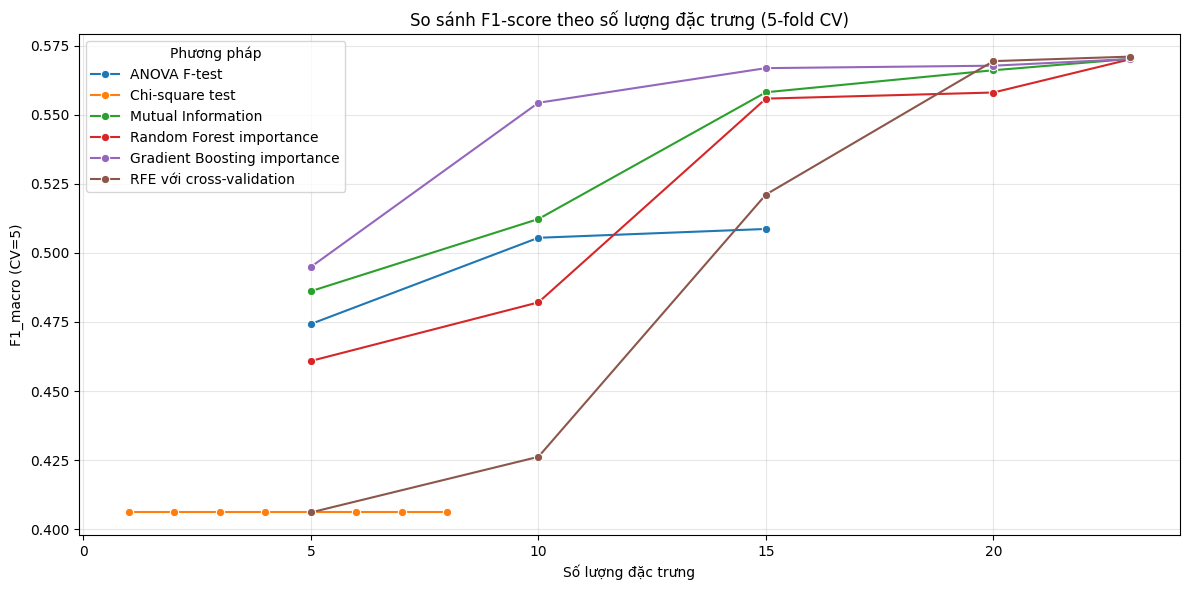

Số thành phần PCA để giữ >=95% phương sai: 20


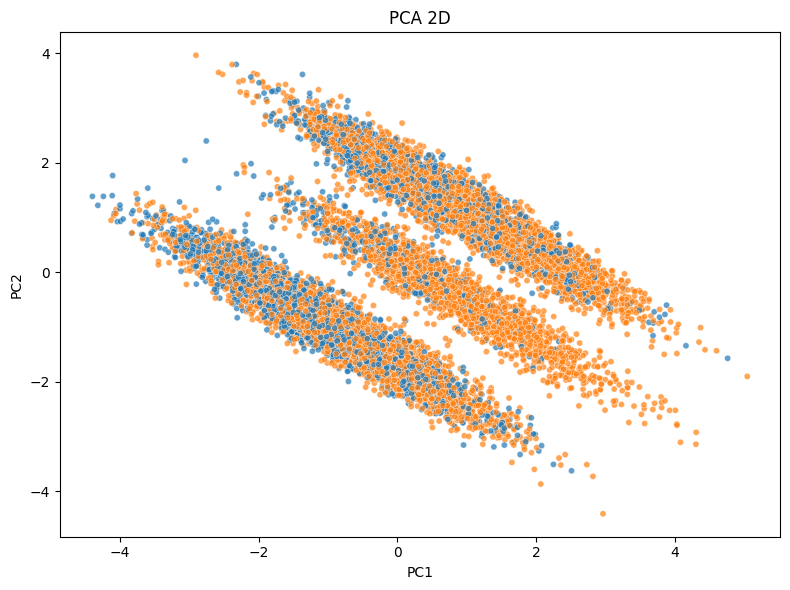

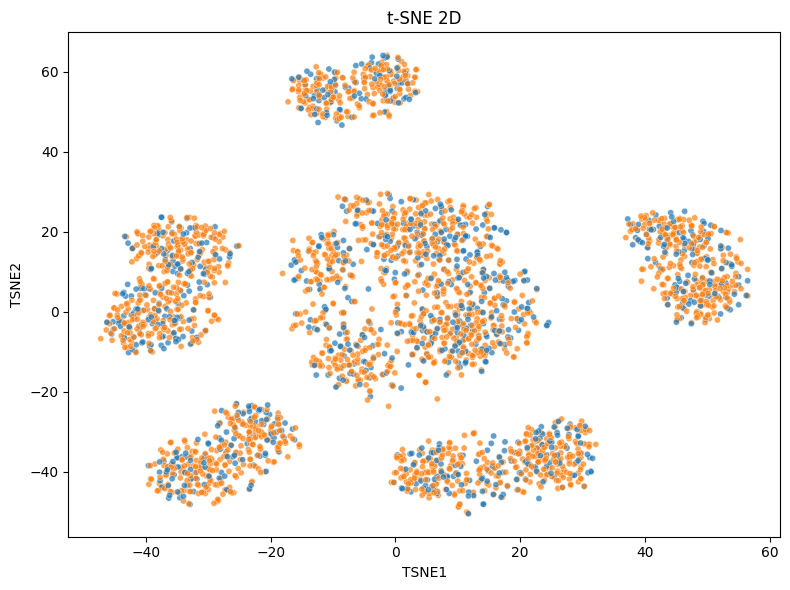

Không chạy được UMAP (thiếu thư viện hoặc lỗi môi trường).
Lý do: No module named 'umap'


In [ ]:
from sklearn.feature_selection import f_classif, chi2, mutual_info_classif, RFECV
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import warnings

warnings.filterwarnings('ignore')

# Dùng dữ liệu theo đúng pipeline: d -> e
if 'df_encoded_processed' in globals():
    fs_base_df = df_encoded_processed.copy()
elif 'df_scaled_processed' in globals():
    fs_base_df = df_scaled_processed.copy()
elif 'df_outlier_processed' in globals():
    fs_base_df = df_outlier_processed.copy()
elif 'df_imputed' in globals():
    fs_base_df = df_imputed.copy()
else:
    fs_base_df = df_work.copy()

# Chọn cột đích tự động 
def pick_target_column_fs(df):
    candidate_targets = ['target', 'label', 'class', 'placement', 'placed', 'status', 'result', 'outcome', 'y']
    for kw in candidate_targets:
        for c in df.columns:
            cl = c.lower()
            if kw == cl or kw in cl:
                return c

    cat_cols_local = df.select_dtypes(exclude=[np.number]).columns.tolist()
    if len(cat_cols_local) > 0:
        nunique_map = {c: df[c].nunique(dropna=True) for c in cat_cols_local}
        valid = [c for c, n in nunique_map.items() if n > 1]
        if len(valid) > 0:
            return sorted(valid, key=lambda x: nunique_map[x])[0]

    num_cols_local = df.select_dtypes(include=[np.number]).columns.tolist()
    if len(num_cols_local) > 0:
        nunique_map = {c: df[c].nunique(dropna=True) for c in num_cols_local}
        valid = [c for c, n in nunique_map.items() if n > 1]
        if len(valid) > 0:
            return sorted(valid, key=lambda x: nunique_map[x])[0]

    raise ValueError('Không tìm được cột đích phù hợp cho bước chọn đặc trưng.')


target_col_fs = pick_target_column_fs(fs_base_df)

# Mã hóa target về số
if pd.api.types.is_numeric_dtype(fs_base_df[target_col_fs]):
    y_fs = pd.to_numeric(fs_base_df[target_col_fs], errors='coerce')
else:
    y_fs = fs_base_df[target_col_fs].astype('category').cat.codes.astype(float)
    y_fs = y_fs.replace(-1, np.nan)

y_fs = y_fs.fillna(y_fs.mode(dropna=True).iloc[0] if y_fs.notna().any() else 0).astype(int)

# Chuẩn bị đặc trưng
X_raw = fs_base_df.drop(columns=[target_col_fs]).copy()
num_cols_fs = X_raw.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_fs = X_raw.select_dtypes(exclude=[np.number]).columns.tolist()

X_num = X_raw[num_cols_fs].apply(pd.to_numeric, errors='coerce')
if X_num.shape[1] > 0:
    X_num = X_num.fillna(X_num.median())

X_cat = X_raw[cat_cols_fs].copy()
for c in X_cat.columns:
    X_cat[c] = X_cat[c].astype(str).fillna('__MISSING__')

# One-hot cho các bước cần đặc trưng phân loại ở dạng số
if len(cat_cols_fs) > 0:
    X_cat_onehot = pd.get_dummies(X_cat, drop_first=True)
else:
    X_cat_onehot = pd.DataFrame(index=X_raw.index)

X_all = pd.concat([X_num, X_cat_onehot], axis=1)

# Lấy mẫu để tăng tốc 
sample_n_fs = min(15000, len(X_all))
sample_idx = X_all.sample(n=sample_n_fs, random_state=42).index
X_num_s = X_num.loc[sample_idx].copy() if X_num.shape[1] > 0 else pd.DataFrame(index=sample_idx)
X_cat_s = X_cat_onehot.loc[sample_idx].copy() if X_cat_onehot.shape[1] > 0 else pd.DataFrame(index=sample_idx)
X_all_s = X_all.loc[sample_idx].copy()
y_s = y_fs.loc[sample_idx].copy()

print(f'Cột đích cho câu e: {target_col_fs}')
print(f'Số mẫu dùng để chọn/đánh giá đặc trưng: {len(X_all_s):,}')
print(f'Số đặc trưng số: {X_num_s.shape[1]} | Số đặc trưng phân loại one-hot: {X_cat_s.shape[1]}')

# Hàm đánh giá F1 theo số đặc trưng
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
clf_eval = LogisticRegression(max_iter=2000)


def eval_curve_by_k(X_df, ranked_features, method_name, k_values):
    rows = []
    max_k = min(len(ranked_features), max(k_values) if len(k_values) > 0 else 0)
    if max_k == 0:
        return pd.DataFrame(columns=['Phương pháp', 'Số đặc trưng', 'F1_macro_CV5'])

    for k in sorted(set([k for k in k_values if 1 <= k <= len(ranked_features)])):
        feat_k = ranked_features[:k]
        X_k = X_df[feat_k]
        scores = cross_val_score(clf_eval, X_k, y_s, cv=cv5, scoring='f1_macro', n_jobs=-1)
        rows.append({
            'Phương pháp': method_name,
            'Số đặc trưng': int(k),
            'F1_macro_CV5': float(scores.mean())
        })

    return pd.DataFrame(rows)


method_rankings = {}

# 1) ANOVA F-test (chỉ thuộc tính số)
if X_num_s.shape[1] > 0:
    f_scores, _ = f_classif(X_num_s, y_s)
    anova_rank = pd.Series(f_scores, index=X_num_s.columns).replace([np.inf, -np.inf], np.nan).fillna(-1e9)
    method_rankings['ANOVA_F'] = {
        'X': X_num_s,
        'ranked_features': anova_rank.sort_values(ascending=False).index.tolist()
    }

# 2) Chi-square (đặc trưng phân loại one-hot, cần không âm)
if X_cat_s.shape[1] > 0:
    scaler_nonneg = MinMaxScaler()
    X_cat_nonneg = pd.DataFrame(
        scaler_nonneg.fit_transform(X_cat_s),
        columns=X_cat_s.columns,
        index=X_cat_s.index
    )
    chi_scores, _ = chi2(X_cat_nonneg, y_s)
    chi_rank = pd.Series(chi_scores, index=X_cat_nonneg.columns).replace([np.inf, -np.inf], np.nan).fillna(-1e9)
    method_rankings['Chi2'] = {
        'X': X_cat_nonneg,
        'ranked_features': chi_rank.sort_values(ascending=False).index.tolist()
    }

# 3) Mutual Information (toàn bộ đặc trưng số hóa)
if X_all_s.shape[1] > 0:
    mi_scores = mutual_info_classif(X_all_s, y_s, random_state=42)
    mi_rank = pd.Series(mi_scores, index=X_all_s.columns).replace([np.inf, -np.inf], np.nan).fillna(-1e9)
    method_rankings['Mutual_Info'] = {
        'X': X_all_s,
        'ranked_features': mi_rank.sort_values(ascending=False).index.tolist()
    }

# 4) Random Forest importance
if X_all_s.shape[1] > 0:
    rf_model = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
    rf_model.fit(X_all_s, y_s)
    rf_rank = pd.Series(rf_model.feature_importances_, index=X_all_s.columns)
    method_rankings['RF_Importance'] = {
        'X': X_all_s,
        'ranked_features': rf_rank.sort_values(ascending=False).index.tolist()
    }

# 5) Gradient Boosting importance
if X_all_s.shape[1] > 0:
    gb_model = GradientBoostingClassifier(random_state=42)
    gb_model.fit(X_all_s, y_s)
    gb_rank = pd.Series(gb_model.feature_importances_, index=X_all_s.columns)
    method_rankings['GB_Importance'] = {
        'X': X_all_s,
        'ranked_features': gb_rank.sort_values(ascending=False).index.tolist()
    }

# 6) RFECV
if X_all_s.shape[1] > 1:
    scaler_std = StandardScaler()
    X_all_std = pd.DataFrame(
        scaler_std.fit_transform(X_all_s),
        columns=X_all_s.columns,
        index=X_all_s.index
    )

    rfecv_est = LogisticRegression(max_iter=2000)
    rfecv = RFECV(
        estimator=rfecv_est,
        step=max(1, int(0.1 * X_all_std.shape[1])),
        cv=3,
        scoring='f1_macro',
        min_features_to_select=max(5, min(10, X_all_std.shape[1] // 5 if X_all_std.shape[1] >= 5 else 1)),
        n_jobs=-1
    )
    rfecv.fit(X_all_std, y_s)

    rfe_rank_df = pd.DataFrame({
        'feature': X_all_std.columns,
        'ranking': rfecv.ranking_
    }).sort_values(['ranking', 'feature']).reset_index(drop=True)

    method_rankings['RFE_CV'] = {
        'X': X_all_std,
        'ranked_features': rfe_rank_df['feature'].tolist()
    }

# Đánh giá F1 theo số lượng đặc trưng
perf_frames = []
for method_name, payload in method_rankings.items():
    X_m = payload['X']
    rank_m = payload['ranked_features']
    n_feat = len(rank_m)

    # Lưới số đặc trưng thích ứng theo từng phương pháp
    if n_feat <= 10:
        k_grid = list(range(1, n_feat + 1))
    else:
        k_grid = sorted(set([5, 10, 15, 20, 30, 40, 50, 75, 100, n_feat]))
        k_grid = [k for k in k_grid if k <= n_feat]

    perf_df = eval_curve_by_k(X_m, rank_m, method_name, k_grid)
    perf_frames.append(perf_df)

perf_all_df = pd.concat(perf_frames, axis=0, ignore_index=True) if len(perf_frames) > 0 else pd.DataFrame()

method_name_map = {
    'ANOVA_F': 'ANOVA F-test',
    'Chi2': 'Chi-square test',
    'Mutual_Info': 'Mutual Information',
    'RF_Importance': 'Random Forest importance',
    'GB_Importance': 'Gradient Boosting importance',
    'RFE_CV': 'RFE với cross-validation'
}

if len(perf_all_df) > 0:
    perf_all_df['Phương pháp'] = perf_all_df['Phương pháp'].map(lambda x: method_name_map.get(x, x))

    best_rows = perf_all_df.sort_values('F1_macro_CV5', ascending=False).groupby('Phương pháp', as_index=False).head(1)
    best_rows = best_rows.sort_values('F1_macro_CV5', ascending=False).reset_index(drop=True)

    print('Hiệu năng tốt nhất theo từng phương pháp lọc/chọn đặc trưng:')
    display(
        best_rows.style
        .set_properties(**{'text-align': 'left'})
        .set_table_styles([
            {'selector': 'th', 'props': [('text-align', 'left')]},
            {'selector': 'td', 'props': [('text-align', 'left')]}
        ])
    )

    plt.figure(figsize=(12, 6))
    sns.lineplot(
        data=perf_all_df,
        x='Số đặc trưng',
        y='F1_macro_CV5',
        hue='Phương pháp',
        marker='o'
    )
    plt.title('So sánh F1-score theo số lượng đặc trưng (5-fold CV)')
    plt.xlabel('Số lượng đặc trưng')
    plt.ylabel('F1_macro (CV=5)')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print('Chưa tạo được bảng hiệu năng theo số lượng đặc trưng.')

# Giảm chiều: PCA, t-SNE, UMAP
if X_all_s.shape[1] >= 2:
    # PCA
    scaler_dr = StandardScaler()
    X_dr_std = scaler_dr.fit_transform(X_all_s)

    pca_full = PCA().fit(X_dr_std)
    cum_var = np.cumsum(pca_full.explained_variance_ratio_)
    n_comp_95 = int(np.argmax(cum_var >= 0.95) + 1)

    pca_2 = PCA(n_components=2, random_state=42)
    X_pca2 = pca_2.fit_transform(X_dr_std)

    pca_plot_df = pd.DataFrame({
        'PC1': X_pca2[:, 0],
        'PC2': X_pca2[:, 1],
        'Nhãn': y_s.values
    })

    print(f'Số thành phần PCA để giữ >=95% phương sai: {n_comp_95}')

    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=pca_plot_df, x='PC1', y='PC2', hue='Nhãn', s=20, alpha=0.7, legend=False)
    plt.title('PCA 2D')
    plt.tight_layout()
    plt.show()

    # t-SNE (trực quan hóa trên mẫu nhỏ hơn để đảm bảo tốc độ)
    tsne_n = min(3000, len(X_all_s))
    tsne_idx = X_all_s.sample(n=tsne_n, random_state=42).index
    X_tsne = X_dr_std[[i for i, idx in enumerate(X_all_s.index) if idx in set(tsne_idx)]]
    y_tsne = y_s.loc[tsne_idx]

    tsne = TSNE(n_components=2, random_state=42, perplexity=30, learning_rate='auto', init='pca')
    X_tsne_2d = tsne.fit_transform(X_tsne)

    tsne_plot_df = pd.DataFrame({
        'TSNE1': X_tsne_2d[:, 0],
        'TSNE2': X_tsne_2d[:, 1],
        'Nhãn': y_tsne.values
    })

    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=tsne_plot_df, x='TSNE1', y='TSNE2', hue='Nhãn', s=20, alpha=0.7, legend=False)
    plt.title('t-SNE 2D')
    plt.tight_layout()
    plt.show()

    # UMAP (nếu dữ liệu lớn và thư viện sẵn có)
    if len(X_all_s) >= 5000:
        try:
            import umap

            umap_n = min(5000, len(X_all_s))
            umap_idx = X_all_s.sample(n=umap_n, random_state=42).index
            X_umap = X_dr_std[[i for i, idx in enumerate(X_all_s.index) if idx in set(umap_idx)]]
            y_umap = y_s.loc[umap_idx]

            umap_model = umap.UMAP(n_components=2, random_state=42)
            X_umap_2d = umap_model.fit_transform(X_umap)

            umap_plot_df = pd.DataFrame({
                'UMAP1': X_umap_2d[:, 0],
                'UMAP2': X_umap_2d[:, 1],
                'Nhãn': y_umap.values
            })

            plt.figure(figsize=(8, 6))
            sns.scatterplot(data=umap_plot_df, x='UMAP1', y='UMAP2', hue='Nhãn', s=20, alpha=0.7, legend=False)
            plt.title('UMAP 2D')
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print('Không chạy được UMAP (thiếu thư viện hoặc lỗi môi trường).')
            print(f'Lý do: {e}')
    else:
        print('Bỏ qua UMAP vì kích thước mẫu chưa đủ lớn theo ngưỡng đặt ra (>= 5000).')
else:
    print('Không đủ số đặc trưng để thực hiện PCA/t-SNE/UMAP.')

**Phân tích kết quả lựa chọn và giảm chiều đặc trưng**

- Theo bảng F1-score CV 5-fold, nhóm phương pháp dựa trên mô hình và MI cho hiệu năng cao hơn nhóm lọc thuần thống kê.
- Phương pháp tốt nhất trong lần chạy này là **RFE_CV** với F1-macro xấp xỉ **0.571**, nhỉnh hơn nhẹ so với Mutual Information, Gradient Boosting và Random Forest importance.
- **ANOVA F-test** cho mức hiệu năng trung bình, trong khi **Chi-square** thấp nhất trên bộ dữ liệu hiện tại (do chỉ khai thác nhóm đặc trưng phân loại one-hot).
- Biểu đồ hiệu năng theo số đặc trưng cho thấy xu hướng chung: khi tăng số đặc trưng, F1-score cải thiện và dần bão hòa quanh vùng 20-23 đặc trưng.

Về giảm chiều:
- **PCA** cho thấy cần khoảng **20 thành phần** để giữ >=95% phương sai.
- **t-SNE** thể hiện cấu trúc cụm trong không gian 2D rõ hơn PCA, phù hợp mục tiêu trực quan hóa.
- **UMAP** chưa chạy được do thiếu thư viện trong môi trường hiện tại (`No module named 'umap'`).

**Kết luận:** ưu tiên RFE_CV hoặc MI/feature importance khi mục tiêu là tối đa F1-score; dùng PCA cho nén chiều tuyến tính và t-SNE cho trực quan hóa phi tuyến.

#### **f) Phát hiện và xử lý mất cân bằng lớp**

Yêu cầu đề bài:
- Áp dụng **SMOTE**, **ADASYN** và **Random Under-sampling**.
- Với mỗi chiến lược, huấn luyện và đánh giá mô hình trên **tập test chưa tái cân bằng**.
- Báo cáo: **Precision**, **Recall**, **F1-macro**, **AUC-ROC**.
- Giải thích vì sao **không resampling trước khi chia train/test**.

**(i) Cơ sở lý thuyết và công thức**

- **Mất cân bằng lớp** xảy ra khi phân phối số mẫu giữa các lớp chênh lệch lớn, làm mô hình thiên lệch về lớp đa số.
- **SMOTE** tạo mẫu thiểu số tổng hợp theo nội suy tuyến tính giữa một điểm thiểu số và láng giềng gần nhất:

$$
x_{new}=x_i+\lambda(x_{zi}-x_i),\quad \lambda\sim U(0,1)
$$

Trong đó:
- $x_i$: điểm thuộc lớp thiểu số gốc.
- $x_{zi}$: một láng giềng gần nhất của $x_i$ trong lớp thiểu số.
- $\lambda$: hệ số nội suy ngẫu nhiên trong $[0,1]$.

- **ADASYN** cũng sinh mẫu tổng hợp như SMOTE nhưng phân bổ số mẫu mới nhiều hơn cho các vùng khó học (vùng có nhiều láng giềng lớp đa số).
- **Random Under-sampling** giảm số mẫu lớp đa số bằng lấy mẫu ngẫu nhiên để cân bằng lại tỉ lệ lớp.

Các chỉ số đánh giá (trên tập test gốc, không tái cân bằng):

$$
\mathrm{Precision}=\frac{TP}{TP+FP},\qquad
\mathrm{Recall}=\frac{TP}{TP+FN}
$$

$$
F1=\frac{2\cdot \mathrm{Precision}\cdot \mathrm{Recall}}{\mathrm{Precision}+\mathrm{Recall}},\qquad
F1_{\text{macro}}=\frac{1}{K}\sum_{k=1}^{K} F1_k
$$

- $TP$: số dự đoán dương đúng.
- $FP$: số dự đoán dương sai.
- $FN$: số mẫu dương bị bỏ sót.
- $K$: số lớp.

AUC-ROC đo chất lượng phân biệt lớp dựa trên đường cong ROC. Với ROC:

$$
\mathrm{TPR}=\frac{TP}{TP+FN},\qquad
\mathrm{FPR}=\frac{FP}{FP+TN}
$$

Trong đó AUC là diện tích dưới đường cong ROC; AUC càng lớn thì khả năng phân biệt lớp càng tốt.

Lý do không resampling trước khi chia train/test:
- Nếu resampling trước split, các mẫu tổng hợp hoặc mẫu được chọn có thể rò rỉ cấu trúc sang test.
- Điều này làm metric bị lạc quan giả tạo (data leakage).
- Quy trình đúng là: **chia train/test trước**, sau đó chỉ resample trên train, và đánh giá trên test giữ nguyên phân phối thực tế.

**(ii) Cài đặt**

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

# Dùng dữ liệu theo pipeline đã xử lý
if 'df_encoded_processed' in globals():
    imb_base_df = df_encoded_processed.copy()
elif 'df_scaled_processed' in globals():
    imb_base_df = df_scaled_processed.copy()
elif 'df_outlier_processed' in globals():
    imb_base_df = df_outlier_processed.copy()
elif 'df_imputed' in globals():
    imb_base_df = df_imputed.copy()
else:
    imb_base_df = df_work.copy()


def pick_target_column_imb(df):
    candidate_targets = ['target', 'label', 'class', 'placement', 'placed', 'status', 'result', 'outcome', 'y']
    for kw in candidate_targets:
        for c in df.columns:
            cl = c.lower()
            if kw == cl or kw in cl:
                return c

    cat_cols_local = df.select_dtypes(exclude=[np.number]).columns.tolist()
    if len(cat_cols_local) > 0:
        nunique_map = {c: df[c].nunique(dropna=True) for c in cat_cols_local}
        valid = [c for c, n in nunique_map.items() if n > 1]
        if len(valid) > 0:
            return sorted(valid, key=lambda x: nunique_map[x])[0]

    num_cols_local = df.select_dtypes(include=[np.number]).columns.tolist()
    if len(num_cols_local) > 0:
        nunique_map = {c: df[c].nunique(dropna=True) for c in num_cols_local}
        valid = [c for c, n in nunique_map.items() if n > 1]
        if len(valid) > 0:
            return sorted(valid, key=lambda x: nunique_map[x])[0]

    raise ValueError('Không tìm được cột đích cho bước mất cân bằng lớp.')


target_col_imb = pick_target_column_imb(imb_base_df)

# Tách X, y
X_imb = imb_base_df.drop(columns=[target_col_imb]).copy()
y_raw = imb_base_df[target_col_imb].copy()

# Mã hóa y về số nếu cần
if pd.api.types.is_numeric_dtype(y_raw):
    y_imb = pd.to_numeric(y_raw, errors='coerce')
else:
    y_imb = y_raw.astype('category').cat.codes.astype(float)
    y_imb = y_imb.replace(-1, np.nan)

y_imb = y_imb.fillna(y_imb.mode(dropna=True).iloc[0] if y_imb.notna().any() else 0).astype(int)

# Chỉ giữ đặc trưng số cho model baseline
X_imb = X_imb.apply(pd.to_numeric, errors='coerce')
X_imb = X_imb.replace([np.inf, -np.inf], np.nan)
X_imb = X_imb.fillna(X_imb.median(numeric_only=True))
X_imb = X_imb.select_dtypes(include=[np.number])

if X_imb.shape[1] == 0:
    raise ValueError('Không còn đặc trưng số hợp lệ để huấn luyện model.')

class_counts = y_imb.value_counts().sort_values(ascending=False)
class_counts_df = class_counts.rename_axis('lop').reset_index(name='so_luong')
n_classes = int(y_imb.nunique())
imb_ratio = float(class_counts.iloc[0] / class_counts.iloc[-1]) if len(class_counts) > 1 else 1.0

print(f'Cột đích dùng cho cân bằng lớp: {target_col_imb}')
print('Phân phối lớp ban đầu:')
display(
    class_counts_df.style
    .set_properties(**{'text-align': 'left'})
    .set_table_styles([
        {'selector': 'th', 'props': [('text-align', 'left')]},
        {'selector': 'td', 'props': [('text-align', 'left')]}
    ])
)
print(f'Tỉ lệ lớp lớn nhất / nhỏ nhất: {imb_ratio:.3f}')

if n_classes <= 1:
    raise ValueError('Chỉ có 1 lớp, không thể đánh giá bài toán mất cân bằng.')

if imb_ratio < 1.5:
    print('Dữ liệu chưa mất cân bằng rõ rệt theo ngưỡng ratio < 1.5. Vẫn chạy so sánh để đối chiếu.')

# Chia train/test TRƯỚC khi resampling để tránh leakage
X_train, X_test, y_train, y_test = train_test_split(
    X_imb, y_imb, test_size=0.2, random_state=42, stratify=y_imb
)

print(f'Kích thước train/test: {X_train.shape[0]:,} / {X_test.shape[0]:,}')
print('Phân phối lớp ở train (trước resampling):')
y_train_counts_df = y_train.value_counts().sort_index().rename_axis('lop').reset_index(name='so_luong')
display(
    y_train_counts_df.style
    .set_properties(**{'text-align': 'left'})
    .set_table_styles([
        {'selector': 'th', 'props': [('text-align', 'left')]},
        {'selector': 'td', 'props': [('text-align', 'left')]}
    ])
)

# Import imbalanced-learn
try:
    from imblearn.over_sampling import SMOTE, ADASYN
    from imblearn.under_sampling import RandomUnderSampler
except Exception as e:
    raise ImportError(
        "Thiếu thư viện imbalanced-learn. Cài đặt bằng: pip install imbalanced-learn\n"
        f"Chi tiết lỗi: {e}"
    )

# Các chiến lược resampling
resamplers = {
    'SMOTE': SMOTE(random_state=42),
    'ADASYN': ADASYN(random_state=42),
    'RandomUnderSampler': RandomUnderSampler(random_state=42)
}

def compute_auc_ovr_macro(model, x_test, y_true, n_class):
    proba = model.predict_proba(x_test)
    if n_class == 2:
        return float(roc_auc_score(y_true, proba[:, 1]))
    return float(roc_auc_score(y_true, proba, multi_class='ovr', average='macro'))

results_imb = []

for method_name, sampler in resamplers.items():
    try:
        # Resampling CHỈ trên train
        X_res, y_res = sampler.fit_resample(X_train, y_train)

        clf = LogisticRegression(max_iter=3000)
        clf.fit(X_res, y_res)

        y_pred = clf.predict(X_test)
        auc_val = compute_auc_ovr_macro(clf, X_test, y_test, n_classes)

        results_imb.append({
            'Chiến lược': method_name,
            'Train size sau resampling': int(len(X_res)),
            'Precision_macro': round(float(precision_score(y_test, y_pred, average='macro', zero_division=0)), 4),
            'Recall_macro': round(float(recall_score(y_test, y_pred, average='macro', zero_division=0)), 4),
            'F1_macro': round(float(f1_score(y_test, y_pred, average='macro', zero_division=0)), 4),
            'AUC_ROC': round(float(auc_val), 4)
        })
    except Exception as e:
        results_imb.append({
            'Chiến lược': method_name,
            'Train size sau resampling': np.nan,
            'Precision_macro': np.nan,
            'Recall_macro': np.nan,
            'F1_macro': np.nan,
            'AUC_ROC': np.nan,
            'Ghi chú': f'Lỗi: {e}'
        })

imb_eval_df = pd.DataFrame(results_imb).sort_values('F1_macro', ascending=False, na_position='last').reset_index(drop=True)

print('Kết quả đánh giá trên tập test gốc (không tái cân bằng):')
display(
    imb_eval_df.style
    .set_properties(**{'text-align': 'left'})
    .set_table_styles([
        {'selector': 'th', 'props': [('text-align', 'left')]},
        {'selector': 'td', 'props': [('text-align', 'left')]}
    ])
)

print('\nGiải thích chống leakage:')
print('- Không resampling trước khi train/test split vì dữ liệu tổng hợp có thể rơi vào cả train và test, gây rò rỉ thông tin.')
print('- Khi đó metric sẽ lạc quan giả tạo do mô hình đã "thấy" cấu trúc điểm test qua mẫu tổng hợp.')
print('- Quy trình đúng: split trước, chỉ resample trên train, test giữ nguyên phân phối thực tế.')

Cột đích dùng cho cân bằng lớp: placement_status
Phân phối lớp ban đầu:


,lop,so_luong
0,0,68473
1,-1,31525


Tỉ lệ lớp lớn nhất / nhỏ nhất: 2.172
Kích thước train/test: 79,998 / 20,000
Phân phối lớp ở train (trước resampling):


,lop,so_luong
0,-1,25220
1,0,54778


Kết quả đánh giá trên tập test gốc (không tái cân bằng):


,Chiến lược,Train size sau resampling,Precision_macro,Recall_macro,F1_macro,AUC_ROC
0,SMOTE,109556,0.602000,0.617400,0.595700,0.657800
1,RandomUnderSampler,50440,0.601600,0.616900,0.595600,0.658100
2,ADASYN,111543,0.601600,0.617600,0.586700,0.657200



Giải thích chống leakage:
- Không resampling trước khi train/test split vì dữ liệu tổng hợp có thể rơi vào cả train và test, gây rò rỉ thông tin.
- Khi đó metric sẽ lạc quan giả tạo do mô hình đã "thấy" cấu trúc điểm test qua mẫu tổng hợp.
- Quy trình đúng: split trước, chỉ resample trên train, test giữ nguyên phân phối thực tế.


#### **g) Xuất dữ liệu cuối sau tiền xử lý**

- Ưu tiên xuất dataset ở cuối pipeline tiền xử lý (thường là sau bước mã hóa ở câu d/e).
- Lưu vào thư mục `../data/processed/` để tách biệt với dữ liệu thô.
- Kèm file metadata để ghi lại phương pháp đã chọn trong pipeline (imputation/outlier/scaling/encoding).

In [17]:
from pathlib import Path
import json

# Chọn dataset cuối để export: ưu tiên pipeline sâu nhất
if 'df_encoded_processed' in globals():
    final_processed_df = df_encoded_processed.copy()
    final_stage = 'encoded'
elif 'df_scaled_processed' in globals():
    final_processed_df = df_scaled_processed.copy()
    final_stage = 'scaled'
elif 'df_outlier_processed' in globals():
    final_processed_df = df_outlier_processed.copy()
    final_stage = 'outlier_processed'
elif 'df_imputed' in globals():
    final_processed_df = df_imputed.copy()
    final_stage = 'imputed'
else:
    final_processed_df = df_work.copy()
    final_stage = 'raw_fallback'

processed_dir = Path('../data/processed')
processed_dir.mkdir(parents=True, exist_ok=True)

csv_out = processed_dir / 'student_placement_processed_final.csv'
meta_out = processed_dir / 'student_placement_processed_final_meta.json'

# Xuất CSV dữ liệu cuối
final_processed_df.to_csv(csv_out, index=False, encoding='utf-8-sig')

# Lưu metadata để truy vết pipeline
metadata = {
    'final_stage': final_stage,
    'shape': {'rows': int(final_processed_df.shape[0]), 'cols': int(final_processed_df.shape[1])},
    'selected_methods': {
        'imputation': best_method if 'best_method' in globals() else None,
        'outlier': best_outlier_method if 'best_outlier_method' in globals() else None,
        'scaler': final_scaler_name if 'final_scaler_name' in globals() else None,
        'encoding': selected_encoding if 'selected_encoding' in globals() else None
    }
}

meta_out.write_text(json.dumps(metadata, ensure_ascii=False, indent=2), encoding='utf-8')

print('Đã xuất dữ liệu cuối sau tiền xử lý:')
print(f'- CSV: {csv_out.resolve()}')
print(f'- Metadata: {meta_out.resolve()}')
print(f"- Stage: {final_stage} | Shape: {final_processed_df.shape}")

Đã xuất dữ liệu cuối sau tiền xử lý:
- CSV: D:\data-mining-lab01\data\processed\student_placement_processed_final.csv
- Metadata: D:\data-mining-lab01\data\processed\student_placement_processed_final_meta.json
- Stage: encoded | Shape: (99998, 24)
